In [1]:
import os
import torch
import random
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm
import copy
import json
from PIL import Image
from learning.src.models.components.extractors.blip import BLIPExtractor
from learning.src.models.components.policies.lstm import LSTMPolicy
from learning.src.models.components.policies.transformer import TransformerPolicy as VITPolicy
from learning.src.data.components.flight_il_dataset_clean import FlightILDataset
from dataclasses import dataclass, asdict
from torchvision import transforms # type: ignore

/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/fairscale/experimental/nn/offload.py:19: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_fwd(orig_func)  # type: ignore
/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/fairscale/experimental/nn/offload.py:30: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_bwd(orig_func)  # type: ignore


In [2]:
from all_in_one import CKPT, ExperimentConfig, set_seed, E2ENet, CSVNet, CSVNet2, infer

In [3]:
# ckpt = CKPT('date', 'time', 'step') # Placeholder for ckpt
ckpt = CKPT('2025-03-27', '07-13-01', 100000)  #VIT 4 actions
config = ExperimentConfig()
config.mode = 'infer' # train, eval, infer, infer_eval
config.policy_name = 'VIT' # LSTM, VIT
config.num_actions = 4

### ---- Testing Simulator Consistency -------

In [4]:
from MCMD_Sim.simulator.simulator_mcmd_exp import MCMDSimSampler, MCMDSimEval, MCMDSimulator
from MCMD_Sim.simulator.utils.schemas import generate_closed_loop_1drone_2ball_env_init
from MCMD_Sim.simulator.utils import SimUtils
from MCMD_Sim.simulator.components import SimDrone
import pandas as pd

pybullet build time: Nov 28 2023 23:52:03


In [5]:
# class SplineSimDrone(SimDrone):
#     def _compute_trajectory(self, turn_only=False, n_points = 8800):
#         """
#         Vectorized trajectory using Sine curve smoothing.
#         """
#         assert hasattr(self, 'target'), 'Drone does not have any target'

#         if turn_only: 
#             return super()._compute_trajectory(turn_only)

#         P0 = np.array(self.traj_pos[-1])  
#         Pd = np.array(self.destination)   
#         Pt = np.array(self.target.loc_abs)

#         c_steps = np.linspace(0, 1, n_points)
#         c_steps = np.column_stack([
#             1 - (1 - c_steps)**3,
#             1 - (1 - c_steps)**5,
#             1 - (1 - c_steps)**20
#         ])
#         t_yaw = np.linspace(0, 1, n_points) ** 1.6

#         c_dir = Pd - Pt
#         d_dir = Pd - P0

#         c_values = (0.2/np.linalg.norm(c_dir)) * np.sin(np.pi * c_steps) 
#         trajectory = P0[None, :] + c_steps * d_dir[None, :] + c_values * c_dir

#         c_ortho = np.array([c_dir[1], -c_dir[0], 0])
#         sgn = np.sign(np.dot(c_ortho, d_dir))
#         dd = 0.8 * c_dir + 2 * c_ortho * sgn

#         delta_xy = Pt[None, :2] + t_yaw[:, None] * dd[None, :2] - trajectory[:, :2]
#         yaw_angles = np.unwrap(np.arctan2(delta_xy[:, 1], delta_xy[:, 0]))

#         # yaw_shift = np.zeros_like(yaw_angles)
#         yaw_diff = yaw_angles[0] - self.traj_rpy[-1][2]
#         print(f'computing traj, starting yaw {self.traj_rpy[-1][2]}, proposed yaw {yaw_angles[0]}, yaw diff {yaw_diff}')
#         t_shift = np.linspace(1, 0, n_points) ** 12
#         yaw_shift = yaw_diff * t_shift
#         yaw_angles = np.unwrap(yaw_angles - yaw_shift)
#         print(f'smoothed yaw {yaw_angles[:5]}')

#         self.traj_pos += trajectory.tolist()
#         self.traj_rpy += [[0, 0, yaw] for yaw in yaw_angles]

#         self.frame_counter += n_points

In [6]:
# class ExpSimSampler(MCMDSimSampler):

#     def __step_simulation(self):
#         self.set_num_steps_until_record()

#         step_counter = 0
#         step_complete = [False for _ in range(len(self.drones))]
#         while not all(step_complete):#recorded_image == False and self.simulation_counter < self.STEPS:
#             self.logger.log_action(self.action)
#             obs, reward, done, info = self.env.step(self.action)
#             if self.simulation_counter == 0: self.logger.log_obs(obs)

#             if self.simulation_counter % self.CTRL_EVERY_N_STEPS == 0:
#                 for j, sim_drone in enumerate(self.drones):
#                     if not step_complete[j]:
#                         state = obs[str(j)]["state"]
#                         self.yaw_all.append((self.simulation_counter,state[9], sim_drone.traj_rpy[self.simulation_counter][-1], state[15]))
#                         self.action[str(j)], _, _ = self.ctrl[j].computeControlFromState(
#                             control_timestep=self.CTRL_EVERY_N_STEPS * self.env.TIMESTEP,
#                             state=state,
#                             target_pos=sim_drone.traj_pos[self.simulation_counter],
#                             target_rpy=sim_drone.traj_rpy[self.simulation_counter]
#                         )
#                     else:
#                         self.action[str(j)] = np.array([0,0,0,0])

#             #* Network Frequency is 30hz
#             if step_counter >= self.num_steps_until_record:# or self.simulation_counter == 1: # and self.simulation_counter>self.env.SIM_FREQ:
#                 for d, sim_drone in enumerate(self.drones):
#                     if not step_complete[d]:
#                         self.export_snap(d)
#                         step_complete[d] = True
#                 # self.logger.log_timestep(self.simulation_counter *  1.0 / SimConfig.SIMULATION_FREQ_HZ)

#             self.simulation_counter += 1
#             for i, step in enumerate(self.STEPS):
#                 if self.simulation_counter >= step: step_complete[i] = True

#             step_counter += 1
#         # print(obs[str(0)]["state"][9], '---------------returning yaw------------------')
#         return obs

#     #------------------------------Simulation All in one run code ---------------------------
#     def run_simulation_to_completion(self, turn_only=False, random_walk=False):
#         """ Creates training images with the stored trajectory """
#         # self.drones = [SplineSimDrone(dro.idx, dro.loc_rel, dro.theta, dro.traj_rpy[-1][-1] - dro.theta)
#         #                 for dro in self.drones]
#         inst = self.precompute_trajectory(turn_only=turn_only, random_walk=random_walk, export_traj=True)
#         self.setup_simulation()
#         self.yaw_all = []

#         while not self.check_exausted_steps():
#             obs = self.__step_simulation()
#             self.logger.log_obs(obs)
#         self.env.close()

#         self.logger.export_plots()
#         self.logger.export_video()

#         return inst

In [7]:
# class ExpSimEval(MCMDSimulator):
#     def __init__(self, init_conditions, record_hz, log_prefix=''):
#         super().__init__(init_conditions, record_hz, log_prefix)
#         self.yaw_all = []
#     def setup_simulation(self):
#         super().setup_simulation()
#         self.drones = [drone.loc_rel for drone in self.drones]
#         self.REC_EVERY_N_STEPS = int(np.floor(self.env.SIM_FREQ / self.record_freq_hz ))
#         imgs = []
#         for i in range(len(self.drones)):
#             im = self.export_snap(i)
#             imgs.append(im[:, :, :3])
#         return imgs
#     def step_action(self, vel_cmds):
#         imgs = []
#         updated_action = False
#         vel_cmd_world = {}
#         while (self.simulation_counter % self.REC_EVERY_N_STEPS) != 0 or not updated_action:
#             self.logger.log_action(self.action)
#             obs, reward, done, info = self.env.step(self.action)
#             state = obs[str(0)]["state"]
#             yaw = state[9]

#             if self.simulation_counter % self.REC_EVERY_N_STEPS== 0:
#                 for d in range(1):
#                     img = self.export_snap(d)
#                     imgs.append(img[:, :, :3])
#                     vel_cmd_world[d] = SimUtils.convert_vel_cmd_to_world_frame(vel_cmds[d], yaw)

#                 self.logger.log_obs(obs)
#                 updated_action = True
                
#             if self.simulation_counter % self.CTRL_EVERY_N_STEPS == 0:
#                 if self.simulation_counter < 100: print(state[9])
#                 for d in range(1):
#                     self.yaw_all.append((self.simulation_counter, state[9], state[15], vel_cmds[d][3]))
#                     self.action[str(d)], _, _ = self.ctrl[d].computeControl(
#                                                         control_timestep=self.CTRL_EVERY_N_STEPS * self.env.TIMESTEP,
#                                                         cur_pos=state[0:3],
#                                                         cur_quat=state[3:7],
#                                                         cur_vel=state[10:13],
#                                                         cur_ang_vel=state[13:16],
#                                                         target_pos=state[0:3],  # same as the current position
#                                                         target_rpy=np.array([0, 0, state[9]]),  # keep current yaw
#                                                         target_vel=vel_cmd_world[d][0:3],
#                                                         target_rpy_rates=np.array([0, 0, vel_cmd_world[d][3]])
#                                                 )
#             self.simulation_counter += 1
#         return imgs
    
#     def close(self):
#         self.env.close()
#         self.logger.export_plots()
#         self.logger.export_video()
#         return ''


In [11]:
random.sample([1, 2], 2)

[2, 1]

In [ ]:
# from MCMD_Sim.simulator.utils import generate_closed_loop_1drone_2ball_env_init, generate_instruction

# sim_objs = [InferenceConfig.obj0, InferenceConfig.obj1]
# init_cond = generate_closed_loop_1drone_2ball_env_init(
#     env_name='samurai',
#     command=InferenceConfig.text_cmd,
#     target_idx=InferenceConfig.target_idx,
#     objs = sim_objs,
#     log_path=os.path.join(config.log_dir),
#     data_path=None
# )
# target = sim_objs[InferenceConfig.target_idx].split(" ")[0]
# text = generate_instruction(target, InferenceConfig.text_cmd)

# log_dir = infer(model, init_cond, text, prefix)
# ExperimentConfig.log_dir = log_dir
# with open(os.path.join(log_dir, "instruction_text.txt"), "w") as file:
#     file.write(text)

In [ ]:
def infer(model, init_cond, text_cmd, prefix=''):
    sim_eval = MCMDSimEval(init_cond, 3, log_prefix=prefix)

    vel_cmd = np.array([[0,0,0,0]])
    image = sim_eval.setup_simulation()[0]
    pred_stops = []
    with torch.no_grad():
        for iter in tqdm(range(100)):
            image = Image.fromarray(image)
            img = image.resize((224, 224))
            img = transforms.ToTensor()(img).to('cuda:0')

            preds = model({"image": img, "text": text_cmd})
            pred_stop = torch.sigmoid(preds.get('stop', torch.tensor([-1.0])))
            pred_stops.append(pred_stop[0].cpu().item())

            vel_cmd = torch.stack([preds["vx"], preds["vy"], preds["vz"], preds["yaw"]], dim=1).cpu().detach().numpy()
            image = sim_eval.step_action(vel_cmd)
            image = image[0]

            if pred_stop > 0.4: break

    log_dir = sim_eval.close()

    # fig, ax = plt.subplots(2, 1, figsize=(15, 10))
    # plt.subplot(2, 1, 1)
    # plt.plot(pred_stops)
    # plt.title('Stop Predition')
    # plt.subplot(2, 1, 2)
    # plt.plot(np.log(np.array(pred_stops)))
    # plt.title('Stop Predition Log Scale')
    # plt.savefig(os.path.join(log_dir, 'pred_stop.jpg'))
    return log_dir#sim_eval.yaw_all

In [9]:
init_cond = generate_closed_loop_1drone_2ball_env_init(
                        env_name='samurai', 
                        log_path='local2/random5',
                        command='right',
                        target_idx=1,
                        objs=['red ball', 'blue ball']
            )

In [10]:
# sim = MCMDSimSampler(init_cond, 3, log_prefix='ALLcollect')

In [11]:
# sim_eval = MCMDSimEval(init_cond, 3, log_prefix='ALLInfer')

In [12]:
# sim.drones[0].traj_rpy

In [13]:
# obs, _, _, _ = sim.env.step({'0': np.array([0,0,0,0])})
# yaw = obs[str(0)]["state"][9]
# obs_eval, _, _, _ = sim_eval.env.step({'0': np.array([0,0,0,0])})
# yaw_eval = obs_eval[str(0)]["state"][9]
# print(yaw_eval)

Target locked on blue ball at (1.9663053949824951, -0.30000000000000004, 1.1285526350951511). Destination (1.9663053949824951, -0.8, 1.1285526350951511)
Drone_0 trajectory computed for target_1
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[[0.         0.         0.72219693]]
(0.7615560867498539, 1.8374953695374352, 1.4413925168440664)
added red ball at (0.7615560867498539, 1.8374953695374352, 1.4413925168440664)
(1.2748480337322523, 1.526800378971094, 1.1285526350951511)
added blue ball at (1.2748480337322523, 1.526800378971094, 1.1285526350951511)


/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/gym/spaces/box.py:73: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(


[[0.         0.         0.72219693]]
(0.7615560867498539, 1.8374953695374352, 1.4413925168440664)
added red ball at (0.7615560867498539, 1.8374953695374352, 1.4413925168440664)
(1.2748480337322523, 1.526800378971094, 1.1285526350951511)
added blue ball at (1.2748480337322523, 1.526800378971094, 1.1285526350951511)


'local2/random5/collect--Go on the right of blue target.\n'

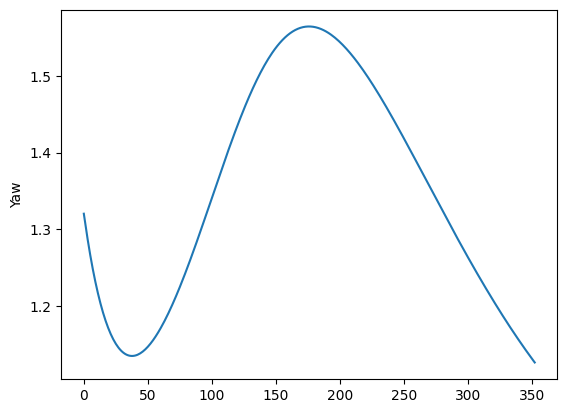

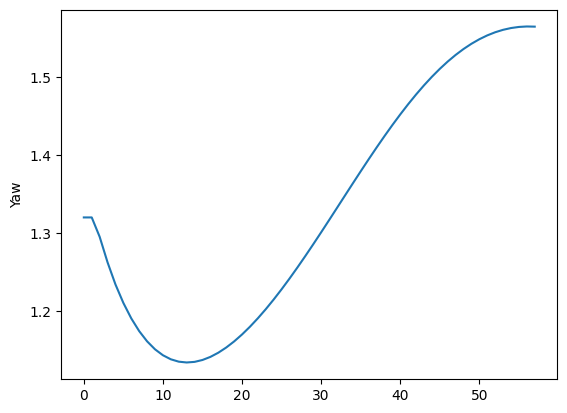

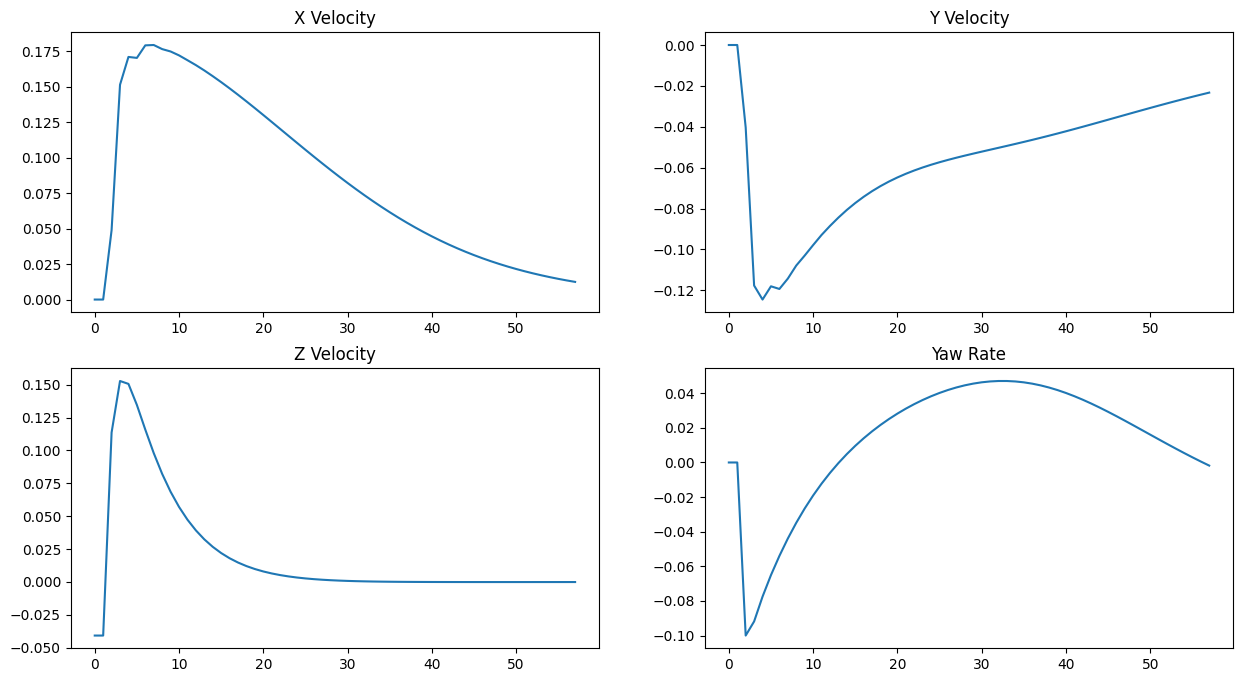

In [14]:
sim = MCMDSimSampler(init_cond, 3, log_prefix='ALLcollect')
sim.run_simulation_to_completion(random_walk=False)

In [15]:
exp_path = os.path.join('local2/random5', os.listdir('local2/random5')[0])
exp_path2 = os.path.join('local2/random2', os.listdir('local2/random2')[0])
exp_path3 = os.path.join('local2/random3', os.listdir('local2/random3')[0])

In [16]:
ep_path = exp_path
print(ep_path)
csv_path = os.path.join(ep_path, 'data', 'data_out.csv')
model = CSVNet2(csv_path)
init_cond = json.load(open(os.path.join(ep_path, 'init_conditions.json'), 'r'))
init_cond['log_dir'] = ep_path

local2/random5/collect


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[[0.         0.         0.72219693]]
(0.7615560867498539, 1.8374953695374352, 1.4413925168440664)
added red ball at (0.7615560867498539, 1.8374953695374352, 1.4413925168440664)
(1.2748480337322523, 1.526800378971094, 1.1285526350951511)
added blue ball at (1.2748480337322523, 1.526800378971094, 1.1285526350951511)


/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/gym/spaces/box.py:73: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(


[[0.         0.         0.72219693]]
(0.7615560867498539, 1.8374953695374352, 1.4413925168440664)
added red ball at (0.7615560867498539, 1.8374953695374352, 1.4413925168440664)
(1.2748480337322523, 1.526800378971094, 1.1285526350951511)
added blue ball at (1.2748480337322523, 1.526800378971094, 1.1285526350951511)


  0%|          | 0/100 [00:00<?, ?it/s]/home/alex/flex/all_in_one.py:223: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  out = {k: torch.tensor([row[i]], dtype=torch.float32) for i, k in enumerate(self.out_keys)}
 56%|█████▌    | 56/100 [00:06<00:05,  8.69it/s]


AttributeError: 'MCMDSimEval' object has no attribute 'yaw_all'

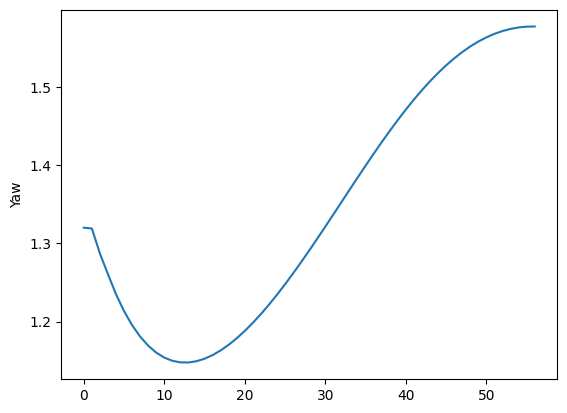

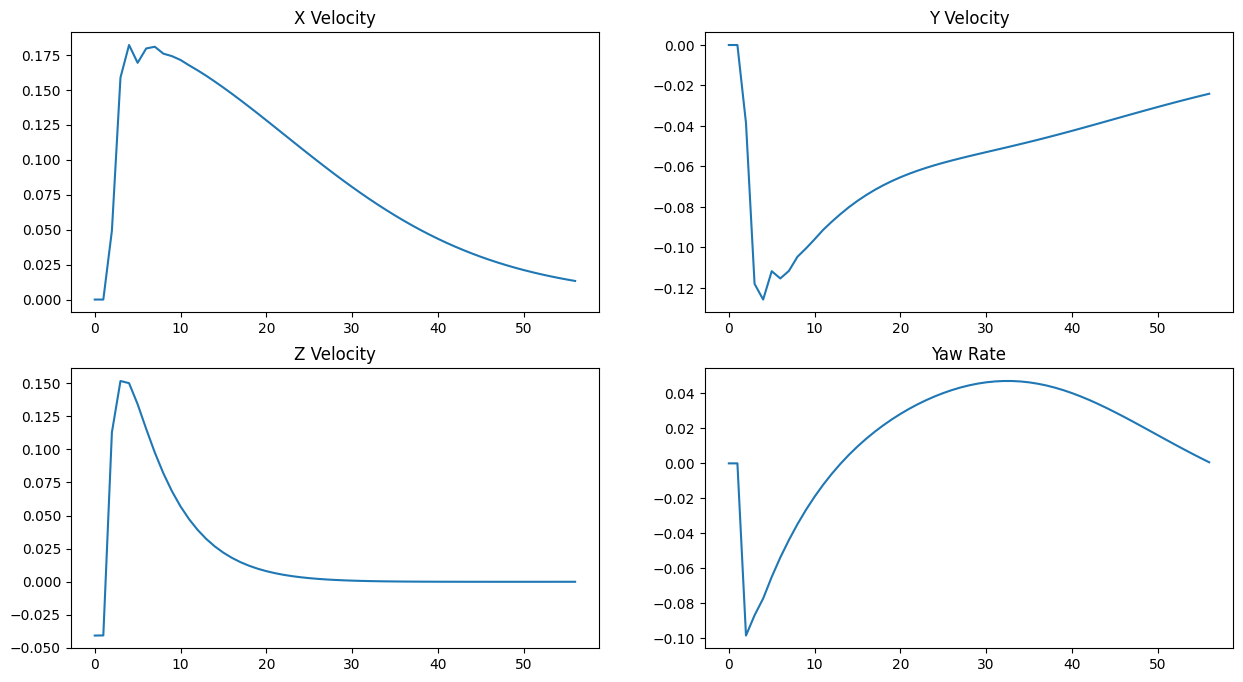

In [17]:
seyaw =infer(model, init_cond, '', prefix='ALLinfer')

In [18]:
# vel_og = pd.read_csv(os.path.join(exp_path, 'data', 'data_out.csv'))
vel_og2 = pd.read_csv(os.path.join(ep_path, 'data', 'data_out.csv'))
# vel_infer = pd.read_csv(os.path.join(exp_path, 'infer', 'data', 'data_out.csv'))
# vel_infer2 = pd.read_csv(os.path.join(exp_path, 'infer2', 'data', 'data_out.csv'))
vel_infer3 = pd.read_csv(os.path.join(ep_path, 'infer', 'data', 'data_out.csv'))

In [19]:
# velc_og = pd.read_csv(os.path.join(exp_path, 'vel_cmds.csv'))
velc_og2 = pd.read_csv(os.path.join(ep_path, 'vel_cmds.csv'))
# velc_infer = pd.read_csv(os.path.join(exp_path, 'infer', 'vel_cmds.csv'))   
# velc_infer2 = pd.read_csv(os.path.join(exp_path, 'infer2', 'vel_cmds.csv'))
velc_infer3 = pd.read_csv(os.path.join(ep_path, 'infer', 'vel_cmds.csv'))

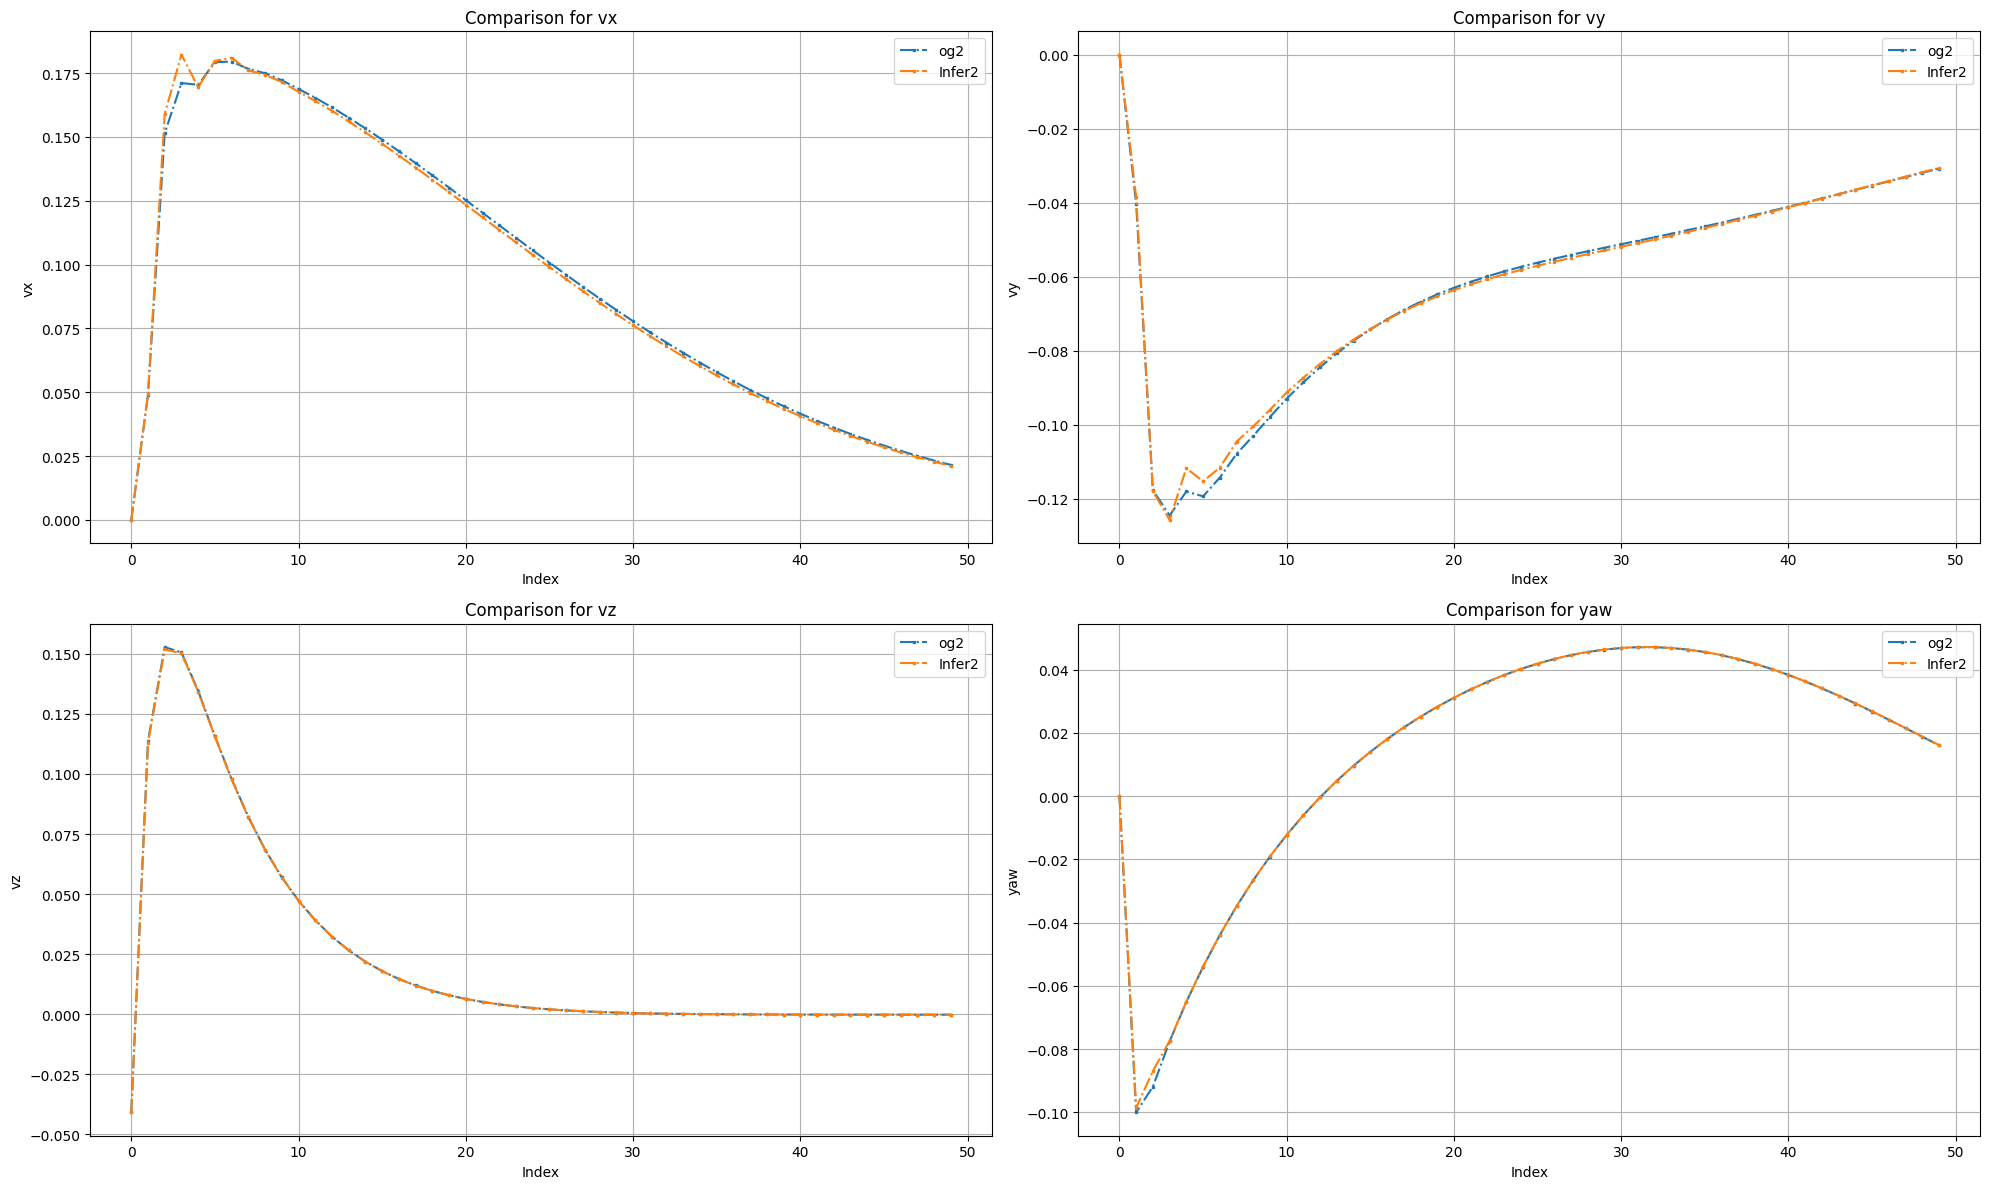

In [20]:
columns = ['vx', 'vy', 'vz', 'yaw']

# Plot the comparisons
plt.figure(figsize=(20, 12))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    # plt.plot(np.arange(50), vel_og.iloc[:50, i], label='og1', linestyle='--', marker='x', markersize=2)
    # plt.plot(np.arange(50), vel_infer.iloc[:50, i], label='Infer', linestyle='-.', marker='s', markersize=2)
    plt.plot(np.arange(50), vel_og2.iloc[:50, i], label='og2', linestyle='-.', marker='s', markersize=2)
    plt.plot(np.arange(50), vel_infer3.iloc[:50, i], label='Infer2', linestyle='-.', marker='s', markersize=2)
    plt.title(f'Comparison for {columns[i]}')
    plt.xlabel('Index')
    plt.ylabel(f'{columns[i]}')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

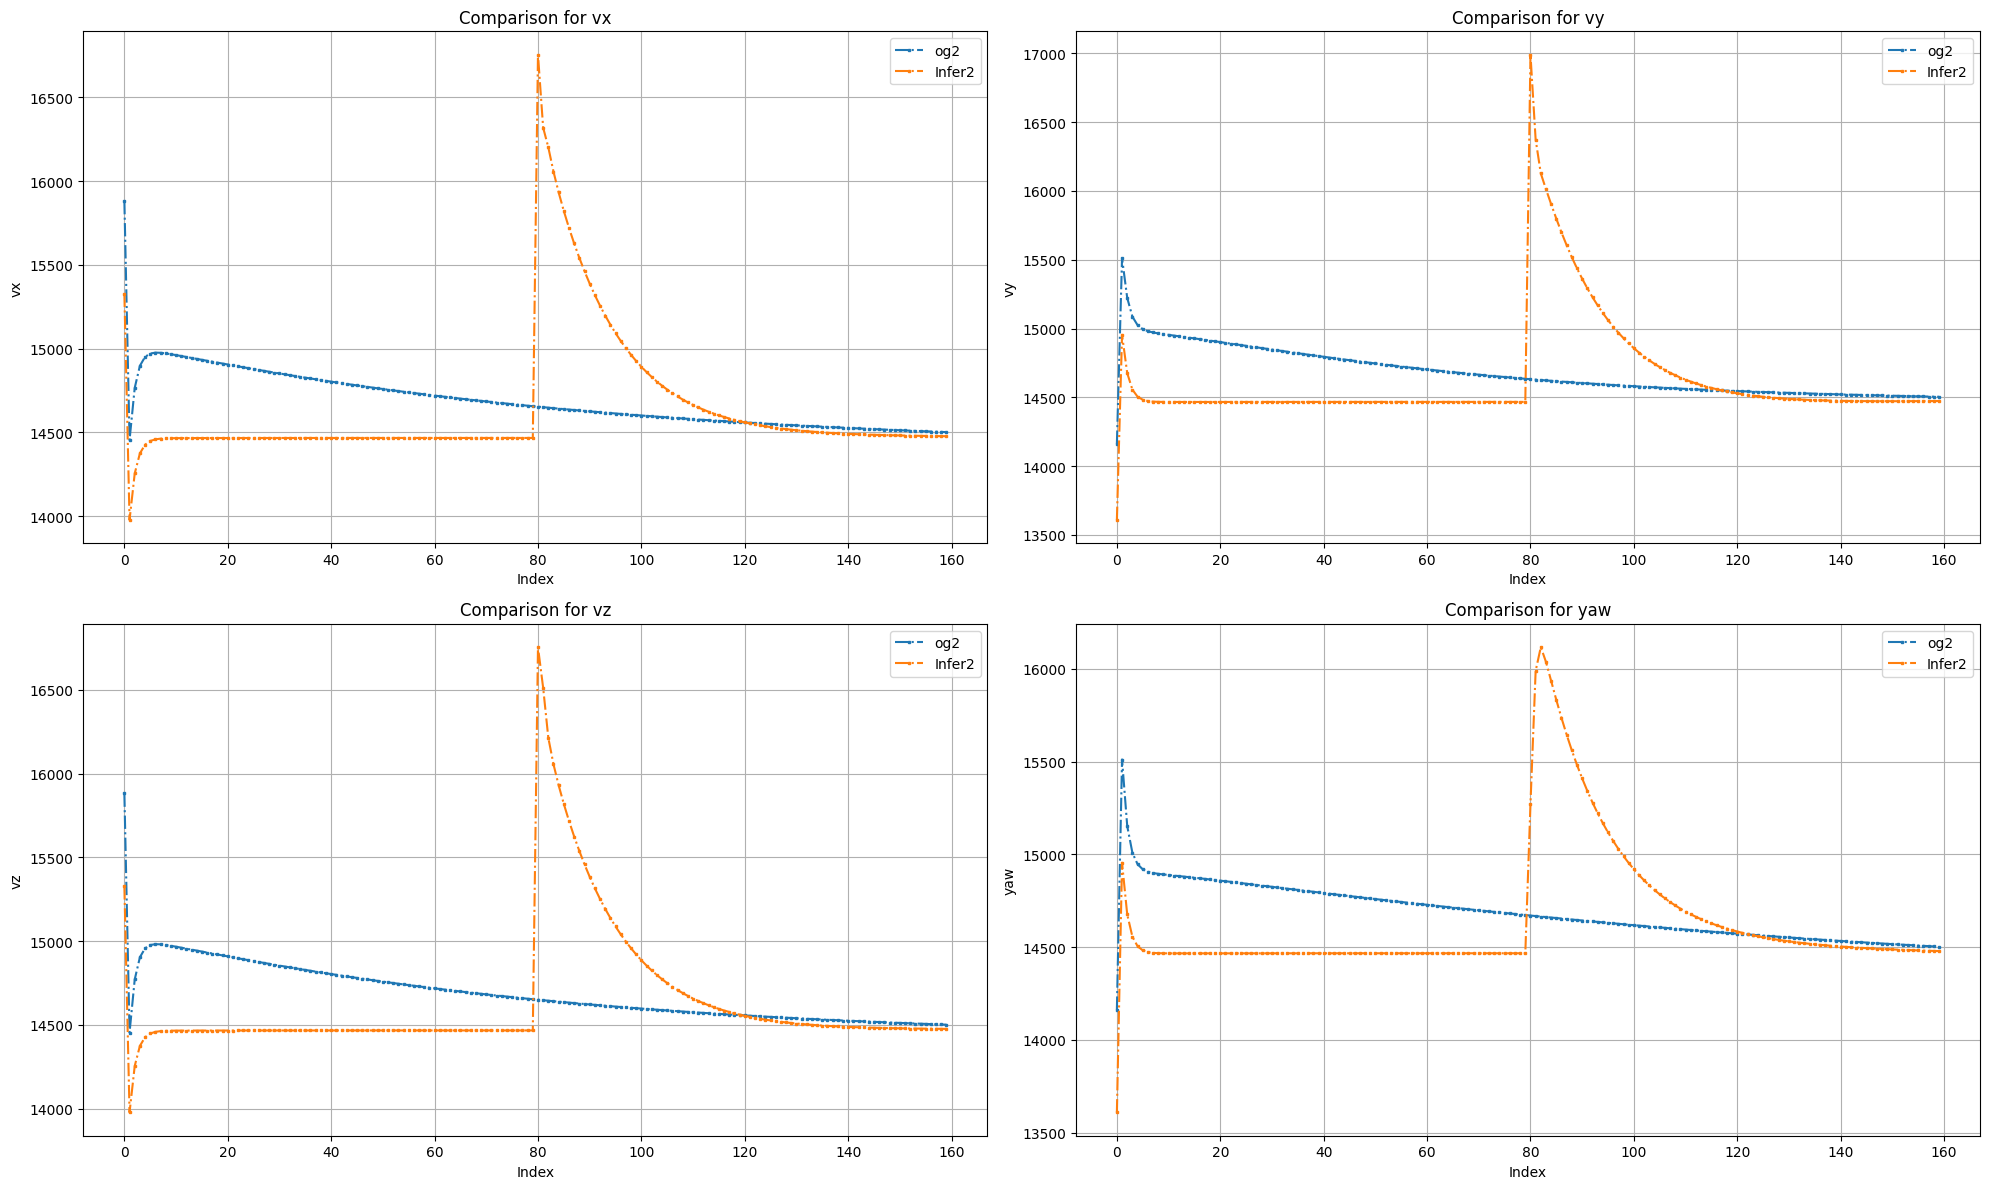

In [21]:
columns = ['vx', 'vy', 'vz', 'yaw']

# Plot the comparisons
plt.figure(figsize=(20, 12))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    # plt.plot(np.arange(500), velc_og.iloc[:500, i], label='og1', linestyle='--', marker='x', markersize=2)
    # plt.plot(np.arange(500), velc_infer.iloc[:500, i], label='Infer', linestyle='-.', marker='s', markersize=2)
    plt.plot(np.arange(160), velc_og2.iloc[:160, i], label='og2', linestyle='-.', marker='s', markersize=2)
    plt.plot(np.arange(160), velc_infer3.iloc[:160, i], label='Infer2', linestyle='-.', marker='s', markersize=2)
    plt.title(f'Comparison for {columns[i]}')
    plt.xlabel('Index')
    plt.ylabel(f'{columns[i]}')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
# columns = ['vx', 'vy', 'vz', 'yaw']

# # Plot the comparisons
# plt.figure(figsize=(20, 12))
# for i in range(4):
#     plt.subplot(2, 2, i + 1)
#     plt.plot(vel_og2.iloc[:, i], label='og1', linestyle='--', marker='x', markersize=2)
#     plt.plot(np.arange(len(vel_og2.iloc[:, i])+1), velc_og2.iloc[::80, i]*1e-5, label='og1c', linestyle='-.', marker='s', markersize=2)
#     plt.title(f'Comparison for {columns[i]}')
#     plt.xlabel('Index')
#     plt.ylabel(f'{columns[i]}')
#     plt.legend()
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

In [23]:
pos_og2 = pd.read_csv(os.path.join(ep_path, 'data', 'pos.csv'))
pos_infer3 = pd.read_csv(os.path.join(ep_path, 'infer', 'data', 'pos.csv'))

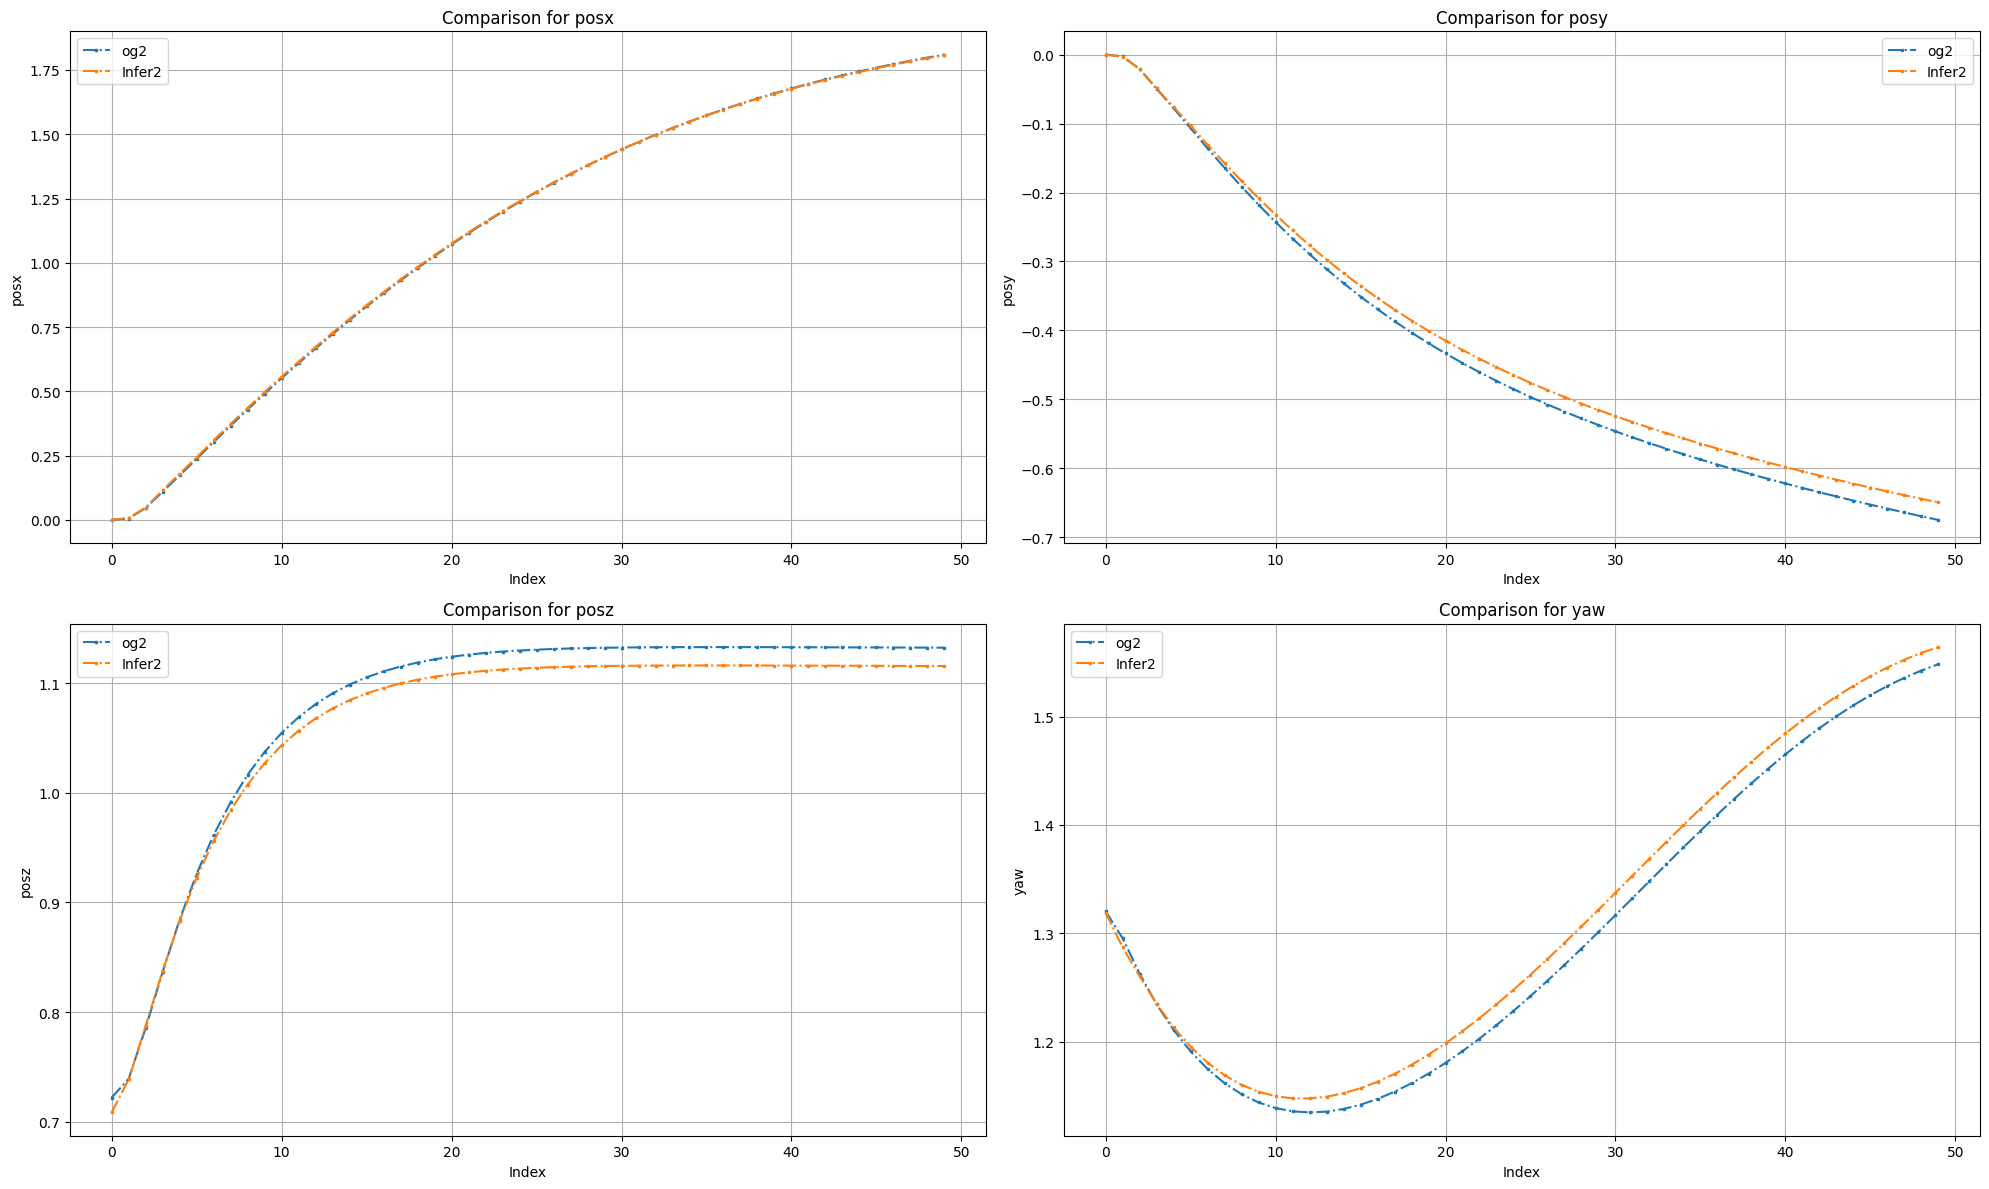

In [24]:
columns = ['posx', 'posy', 'posz', 'yaw']

# Plot the comparisons
plt.figure(figsize=(20, 12))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.plot(np.arange(50), pos_og2.iloc[:50, i], label='og2', linestyle='-.', marker='s', markersize=2)
    plt.plot(np.arange(50), pos_infer3.iloc[:50, i], label='Infer2', linestyle='-.', marker='s', markersize=2)
    plt.title(f'Comparison for {columns[i]}')
    plt.xlabel('Index')
    plt.ylabel(f'{columns[i]}')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [25]:
# sim.drones[0].traj_rpy[:100, 2]

In [26]:
def plot_graph(data, title):
    plt.figure(figsize=(7, 5))
    for lbl in data:
        plt.plot(data[lbl], label=lbl, marker='o')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

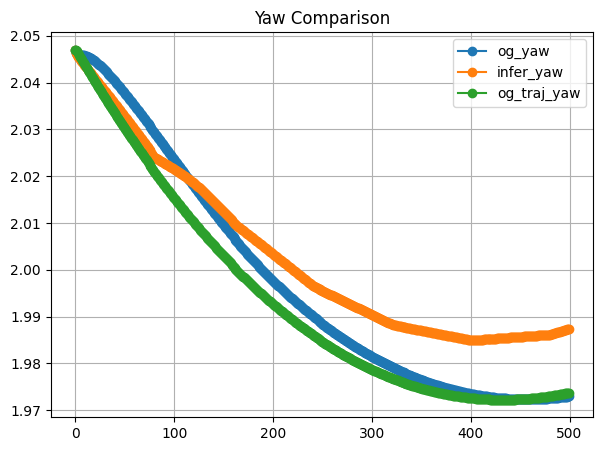

In [27]:
plot_graph(
    {
        'og_yaw': [row[1] for row in sim.yaw_all[:500]],
        'infer_yaw': [row[1] for row in seyaw[:500]],
        'og_traj_yaw': [row[2] for row in sim.yaw_all[:500]],
    }, 'Yaw Comparison'
)

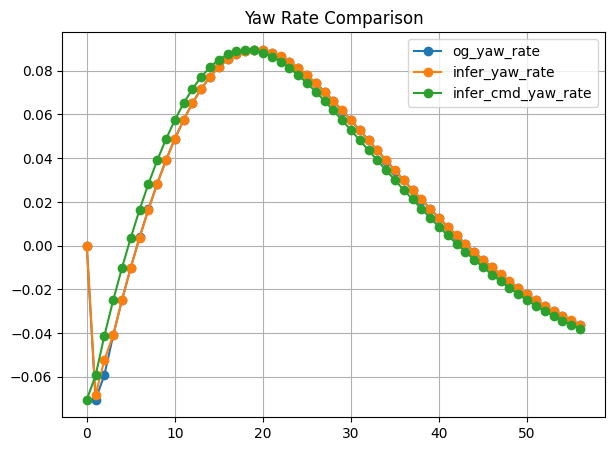

In [28]:
plot_graph(
    {
        'og_yaw_rate': [row[3] for row in sim.yaw_all[::80]],
        'infer_yaw_rate': [row[2] for row in seyaw[::80]],
        'infer_cmd_yaw_rate': [row[3] for row in seyaw[::80]],
    }, 'Yaw Rate Comparison'
)

In [29]:
# seyaw

In [146]:
sim.drones[0].traj_rpy

array([[0.        , 0.        , 1.46615389],
       [0.        , 0.        , 1.02110211],
       [0.        , 0.        , 1.02123373],
       ...,
       [0.        , 0.        , 1.28409856],
       [0.        , 0.        , 1.2840085 ],
       [0.        , 0.        , 1.28391847]])

In [30]:
# sim.logger.vel_array

In [31]:
# sim.logger.global_pos_array

In [44]:
init_cond['theta_environment'] + init_cond['theta_offset']

-2.59933023085502

In [34]:
# pos_infer3.iloc[:50, 3] - pos_og2.iloc[:50, 3]

In [145]:
import torch
import cv2
import numpy as np
import matplotlib.cm as cm

def make_colormap_video_grid(tensor_list, save_path='video_grid.mp4', fps=10, cmap='viridis', upscale_factor=20):
    """
    Create an MP4 video where each frame is a color-mapped h×w tensor, upscaled for blocky grid visualization.

    Args:
        tensor_list: list of (h, w) tensors
        save_path: output video filename
        fps: frames per second
        cmap: matplotlib colormap name
        upscale_factor: integer factor to upscale (h, w) for non-blurry display
    """
    h, w = tensor_list[0].shape
    out_h, out_w = h * upscale_factor, w * upscale_factor
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(save_path, fourcc, fps, (out_w, out_h), isColor=True)

    colormap = cm.get_cmap(cmap)

    for t in tensor_list:
        arr = t.detach().cpu().numpy()
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-5)
        arr_colored = colormap(arr)[:, :, :3]  # RGB
        arr_colored = (arr_colored * 255).astype(np.uint8)

        # Upscale using NEAREST to preserve grid/block effect
        arr_colored_up = cv2.resize(arr_colored, (out_w, out_h), interpolation=cv2.INTER_NEAREST)
        arr_bgr = cv2.cvtColor(arr_colored_up, cv2.COLOR_RGB2BGR)

        out.write(arr_bgr)

    out.release()
    print(f"Saved crisp grid-style video to {save_path}")


In [ ]:
# make_colormap_video_grid(results)

Saved crisp grid-style video to video_grid.mp4


/tmp/ipykernel_1478351/963924967.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


In [1]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

In [101]:
from all_in_one import E2ENet, CKPT
import torch
from learning.src.models.components.policies.svit3 import SViTPolicy as VITPolicy
ckpt = CKPT('2025-04-14', '02-07-39', '950000', policy = ('VIT', 4), mode = 'infer')
device = torch.device('cuda:0')

In [102]:
policy = VITPolicy(cfg=ckpt.policy_cfg)
model = E2ENet(policy, device, feature_extraction=False)
model.load_checkpoint(ckpt.path, new_ckpt_mode=True)

Checkpoint loaded: /home/alex/flex/local/train_flight/2025-04-14/02-07-39/checkpoints/step_950000.ckpt


In [72]:
model({'image': torch.randn(1, 768, 8, 8).to(device), 'text': 'above---red ball'})

{'vx': tensor([0.0647], device='cuda:0', grad_fn=<SelectBackward0>),
 'vy': tensor([0.0315], device='cuda:0', grad_fn=<SelectBackward0>),
 'vz': tensor([0.0236], device='cuda:0', grad_fn=<SelectBackward0>),
 'yaw': tensor([0.0978], device='cuda:0', grad_fn=<SelectBackward0>)}

In [82]:
test = []
test2 = []
def hook(module, input, output):
    test.append(input)
    test2.append(output)
    return output

model.policy.transformer.register_forward_hook(hook)

In [83]:
model.policy(torch.randn(1, 64, 8, 8).to(device), ['left'])

tensor([[0.0596, 0.0237, 0.0064, 0.0762]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [84]:
test[0][0].shape

torch.Size([1, 65, 128])

In [85]:
test2[0].shape

torch.Size([1, 65, 128])

In [79]:
model.policy.transformer(torch.randn(1, 65, 128).to(device)).shape

torch.Size([1, 65, 128])

In [68]:
model

E2ENet(
  (extractor): BLIPExtractor(
    (last_linear_layer): Conv2d(768, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (policy): SViTPolicy(
    (to_patch_embedding): Sequential(
      (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=1, p2=1)
      (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (dir_proj): Linear(in_features=3, out_features=128, bias=True)
    (transformer): Transformer(
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (layers): ModuleList(
        (0-2): 3 x ModuleList(
          (0): Attention(
            (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attend): Softmax(dim=-1)
            (to_qkv): Linear(in_features=128, out_features=480, bias=False)
            (to_out): Linear(in_features=160, out_features=128, bias=False)
          )
          (1): Feed

In [5]:
# dir_vocab = {'left': 0, 'right': 1, 'above': 2, 'below': 3, 'towards': 4}
# dir_tensor = torch.eye(5).to(device, dtype=torch.float32)

In [6]:
dir_vocab = {'left': [1, -1, 0], 'right': [1, 1, 0], 'above': [1, 0, 1], 'below': [1, 0, -1], 'towards': [1, 0, 0]}
dir_tensor = torch.tensor(list(dir_vocab.values())).to(device, dtype=torch.float32)

In [7]:
dir_projections = model.policy.dir_proj(dir_tensor)

In [8]:
dir_projections.shape

torch.Size([5, 128])

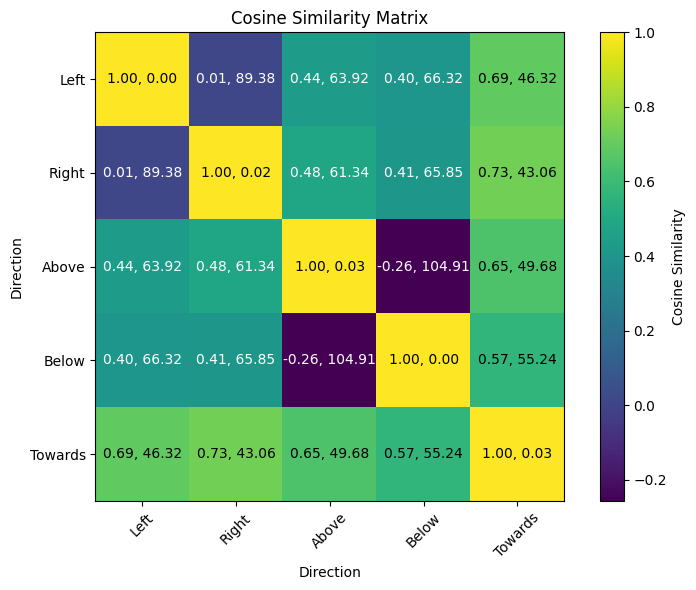

In [9]:
dir_projections = dir_projections / dir_projections.norm(dim=1, keepdim=True)
cos_sim_matrix = dir_projections @ dir_projections.T
cos_sim_matrix_np = cos_sim_matrix.detach().cpu().numpy()

labels = ['Left', 'Right', 'Above', 'Below', 'Towards']
plt.figure(figsize=(8, 6))
plt.imshow(cos_sim_matrix_np, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Cosine Similarity')
plt.title('Cosine Similarity Matrix')

# Add text values on cells
for i in range(len(labels)):
    for j in range(len(labels)):
        value = [cos_sim_matrix_np[i, j]]
        value.append(np.arccos(value[0]) * 180 / np.pi)
        plt.text(j, i, f"{value[0]:.2f}, {value[1]:.2f}", ha='center', va='center', color='white' if value[0] < 0.5 else 'black', fontsize=10)

# Axis labels
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels)
plt.xlabel('Direction')
plt.ylabel('Direction')

plt.tight_layout()
plt.show()


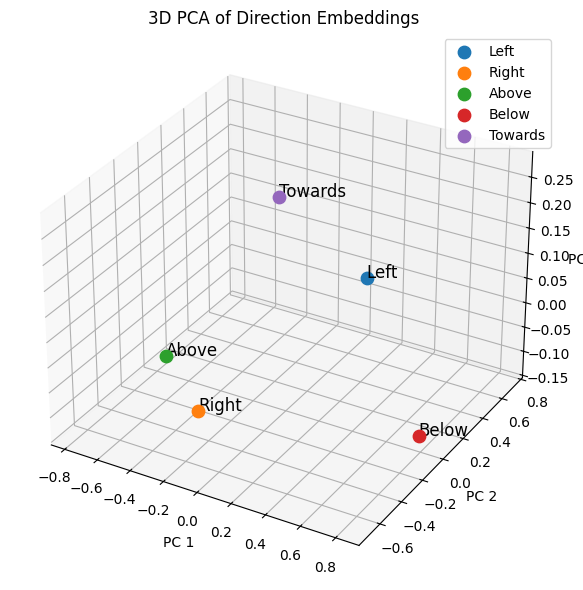

In [10]:
pca = PCA(n_components=3)
dir_proj_3d = pca.fit_transform(dir_projections.detach().cpu().numpy())

# 3D Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot each point with label
for i, (x, y, z) in enumerate(dir_proj_3d):
    ax.scatter(x, y, z, label=labels[i], s=80)
    ax.text(x, y, z, labels[i], fontsize=12)

ax.set_title("3D PCA of Direction Embeddings")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1478351/3010088754.py:14: RuntimeWarning: invalid value encountered in arccos
  value.append(np.arccos(value[0]) * 180 / np.pi)


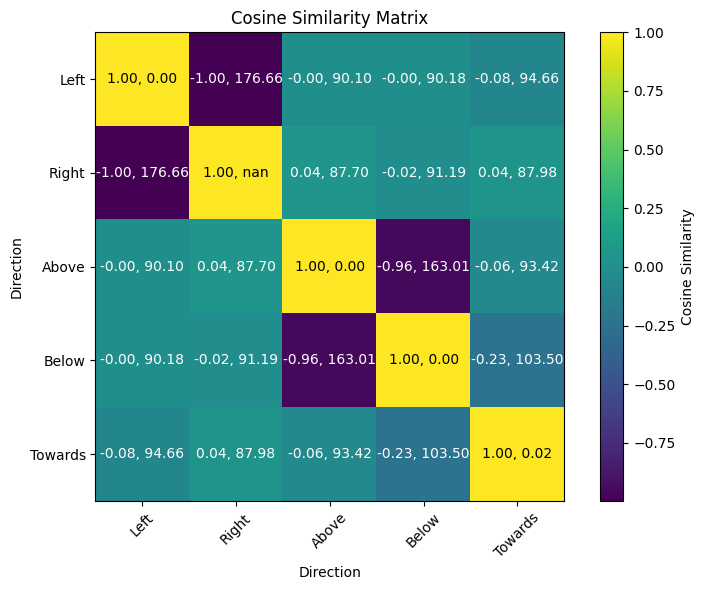

In [11]:
dir_proj_3dn = dir_proj_3d / np.linalg.norm(dir_proj_3d, axis=1, keepdims=True)
cos_sim_matrix_np = dir_proj_3dn @ dir_proj_3dn.T

labels = ['Left', 'Right', 'Above', 'Below', 'Towards']
plt.figure(figsize=(8, 6))
plt.imshow(cos_sim_matrix_np, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Cosine Similarity')
plt.title('Cosine Similarity Matrix')

# Add text values on cells
for i in range(len(labels)):
    for j in range(len(labels)):
        value = [cos_sim_matrix_np[i, j]]
        value.append(np.arccos(value[0]) * 180 / np.pi)
        plt.text(j, i, f"{value[0]:.2f}, {value[1]:.2f}", ha='center', va='center', color='white' if value[0] < 0.5 else 'black', fontsize=10)

# Axis labels
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels)
plt.xlabel('Direction')
plt.ylabel('Direction')

plt.tight_layout()
plt.show()

In [103]:
extract_hooks_outputs = []
def extractor_hook_fn(module, input, output):
    extract_hooks_outputs.append(output)
    return output
# model.extractor.last_linear_layer.register_forward_hook(extractor_hook_fn)
model.policy.transformer.register_forward_hook(extractor_hook_fn)

In [104]:
run_path = '/home/alex/flex/BLIP2_Features/train/above_blue/above_0blue_2025_04_09_02_15_09'
label = 'above'

In [105]:
for f in sorted(os.listdir(run_path)):
    feat = torch.load(os.path.join(run_path, f), map_location='cpu', weights_only=False)
    feat = model.extractor.last_linear_layer(feat.to(device))
    _ = model.policy(feat, [label])

In [106]:
len(extract_hooks_outputs)

44

In [107]:
extract_hooks_outputs[1].shape

torch.Size([1, 65, 128])

In [108]:
def reduce_channels_to_3PC(tensor_list):
    reduced_list = []

    for tensor in tensor_list:
        fmap = tensor.squeeze(0).detach().cpu()
        fmap_reshaped = fmap.view(65, -1)
        pca = PCA(n_components=3)
        fmap_rgb = pca.fit_transform(fmap_reshaped[:64, :])
        fmap_rgb = torch.tensor(fmap_rgb.T).view(1, 3, 8, 8)
        reduced_list.append(fmap_rgb)

    return reduced_list


In [36]:
def reduce_feat_dim_to_3PC(tensor_list):
    reduced_list = torch.stack(tensor_list).detach().cpu().squeeze(1)
    pca = PCA(n_components=3)
    reduced_list = pca.fit_transform(reduced_list)
    return torch.tensor(reduced_list)

In [50]:
torch.stack(extract_hooks_outputs).shape

torch.Size([44, 1, 64, 128])

In [109]:
extract_hooks_3pc = reduce_channels_to_3PC(extract_hooks_outputs)

In [110]:
extract_hooks_3pc[0].shape

torch.Size([1, 3, 8, 8])

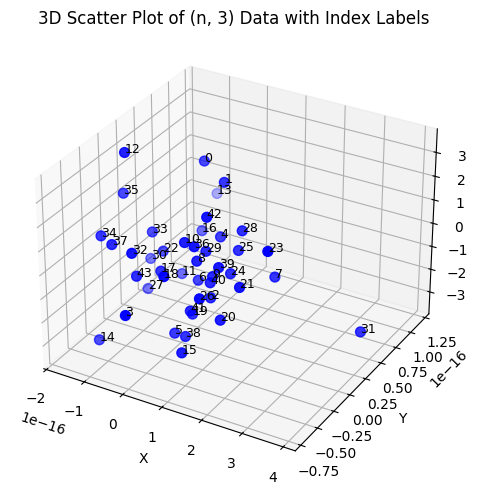

In [111]:
data = torch.stack(extract_hooks_3pc).view(-1, 3, 64).mean(dim=-1)  # assume shape is (n, 3)
x, y, z = data[:, 0], data[:, 1], data[:, 2]

# Create 3D scatter plot
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='blue', s=50)

# Annotate each point with its index
for i in range(len(data)):
    ax.text(x[i], y[i], z[i], str(i), fontsize=9, color='black')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter Plot of (n, 3) Data with Index Labels')
plt.tight_layout()
plt.show()


In [112]:
ball_path = []
for t in extract_hooks_3pc:
    summed = t.sum(dim=0)  # (8,8)
    idx = torch.argmax(summed)
    y, x = divmod(idx.item(), 8)
    ball_path.append((x, y))


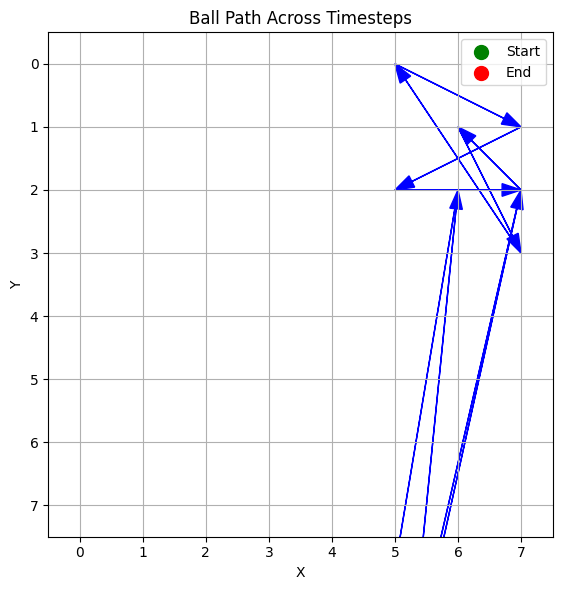

In [113]:
# Separate x and y coordinates
x_coords = [p[0] for p in ball_path]
y_coords = [p[1] for p in ball_path]

# Plot with arrows
plt.figure(figsize=(6, 6))
for i in range(len(ball_path) - 1):
    x0, y0 = ball_path[i]
    x1, y1 = ball_path[i + 1]
    plt.arrow(x0, y0, x1 - x0, y1 - y0, head_width=0.2, length_includes_head=True, color='blue')

# Mark starting and ending points
plt.scatter(x_coords[0], y_coords[0], color='green', label='Start', s=100)
plt.scatter(x_coords[-1], y_coords[-1], color='red', label='End', s=100)

# Grid setup
plt.xlim(-0.5, 7.5)
plt.ylim(7.5, -0.5)  # Flip y-axis for image-like layout
plt.xticks(range(8))
plt.yticks(range(8))
plt.grid(True)
plt.legend()
plt.title("Ball Path Across Timesteps")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()


In [114]:
results = []
n = len(extract_hooks_outputs)
for t in extract_hooks_3pc:
    fmap = t[0]  # shape: (64, 8, 8)
    fmap = fmap.permute(1, 2, 0)  # shape: (8, 8, 64)

    sim_map = torch.zeros(8, 8)
    for i in range(8):
        for j in range(8):
            center = fmap[i, j]
            local_sims = []
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    ni, nj = i + dx, j + dy
                    if 0 <= ni < 8 and 0 <= nj < 8 and (ni, nj) != (i, j):
                        neighbor = fmap[ni, nj]
                        cos_sim = torch.nn.functional.cosine_similarity(center, neighbor, dim=0)
                        local_sims.append(cos_sim.item())
            sim_map[i, j] = sum(local_sims) / len(local_sims) if local_sims else 0
    results.append(sim_map)


In [132]:
pseudo_logit = torch.stack(results)[:, :7, :].to(torch.float32).mean(dim=(1, 2))
pseudo_logit = pseudo_logit - pseudo_logit.min()
pseudo_logit = pseudo_logit / pseudo_logit.max()
pseudo_logit = 2 * pseudo_logit - 1.0

In [134]:
pseudo_logit

tensor([ 0.2321, -0.0946, -0.0771, -0.0195, -0.3685, -0.5430, -0.4742, -0.2757,
        -0.2653, -0.2531, -0.4897, -0.5866, -0.2464, -0.5785,  0.1693, -0.2626,
         0.0922, -0.4175, -0.3819, -0.3895,  0.0069, -0.6641, -0.6667, -0.3290,
        -0.6265, -0.3766, -0.7980, -0.8011, -1.0000, -0.9459, -0.4208, -0.7971,
        -0.6236, -0.6718, -0.3577,  0.0279, -0.0312,  0.2077,  0.4507,  0.2320,
         0.8055,  1.0000,  0.5971,  0.7181])

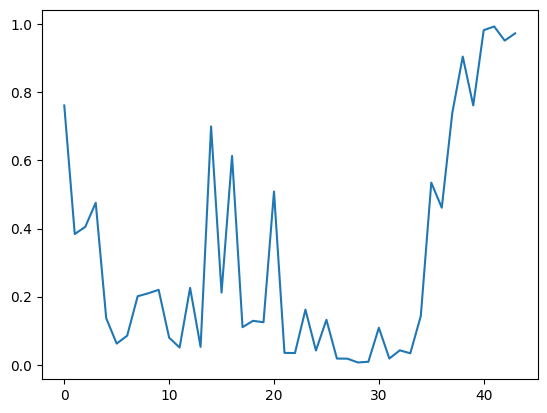

In [136]:
plt.plot(torch.sigmoid(pseudo_logit * 5))

In [138]:
results.shape

AttributeError: 'list' object has no attribute 'shape'

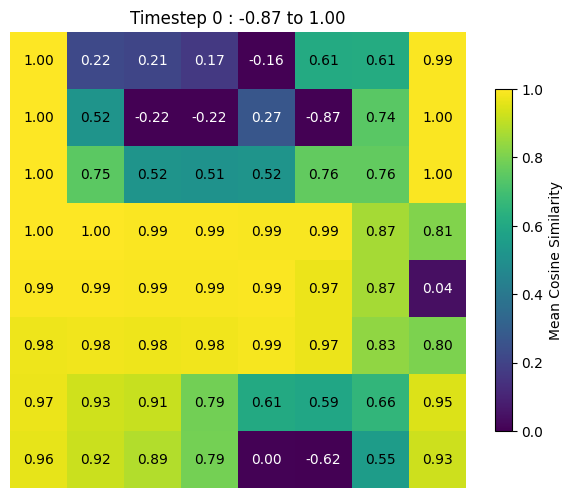

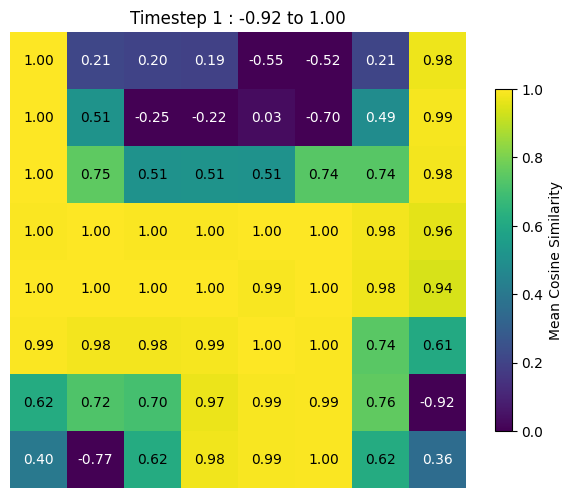

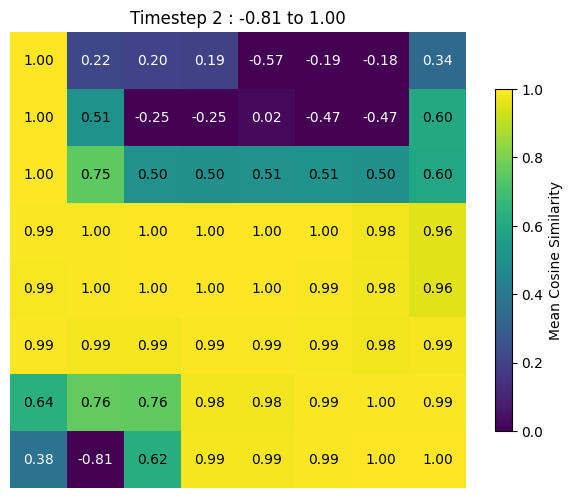

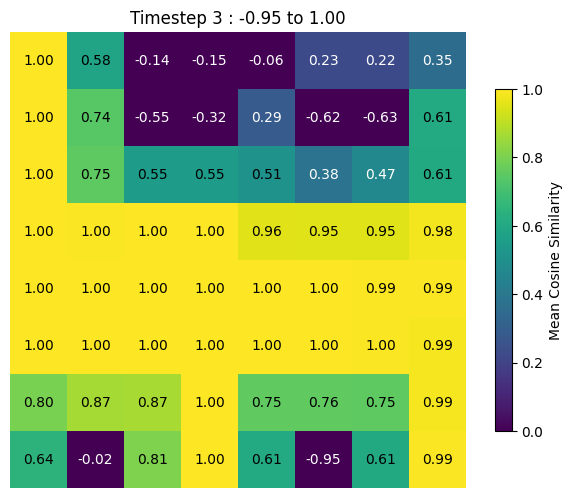

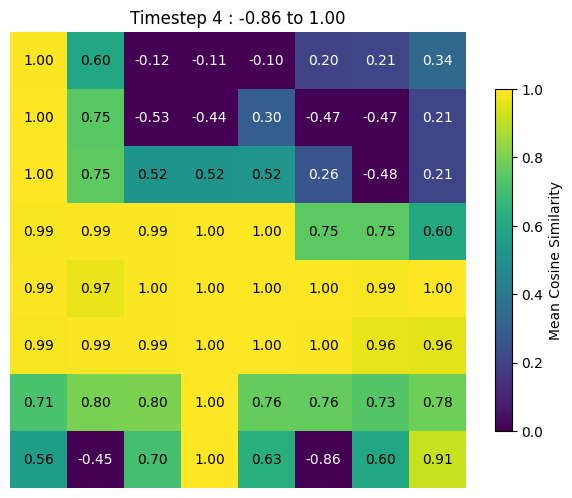

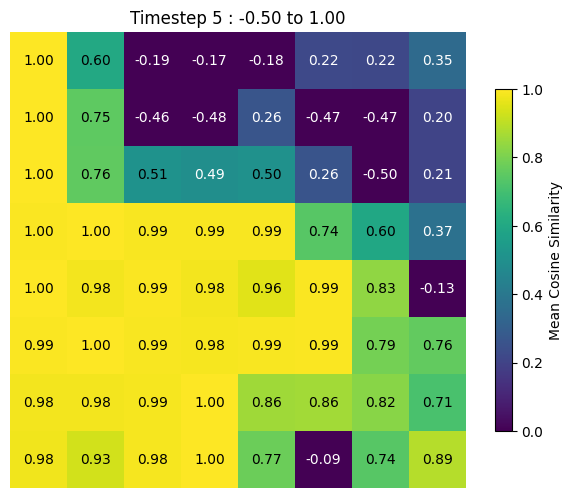

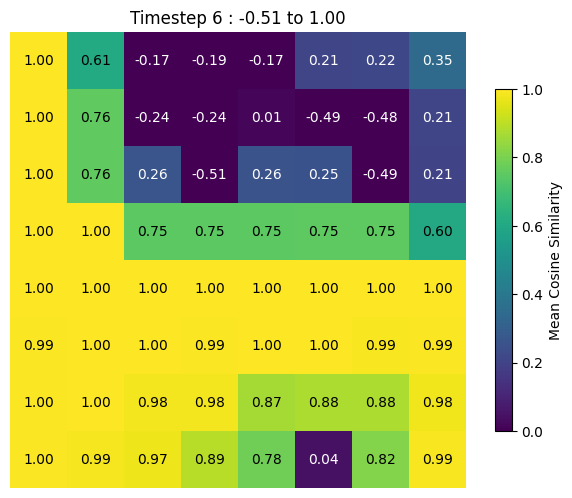

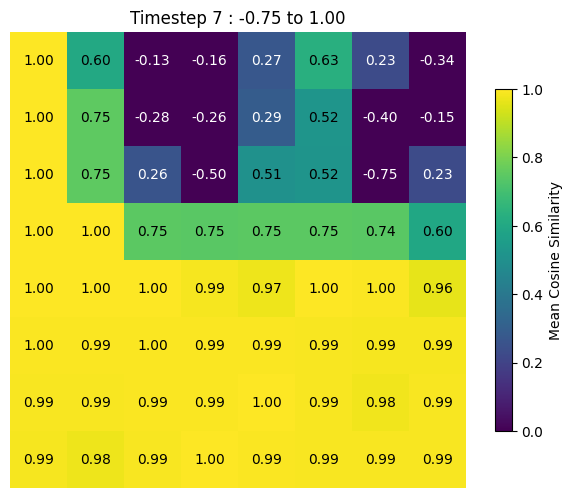

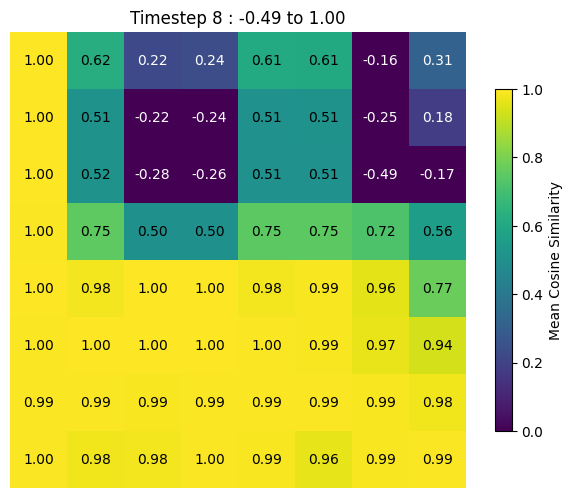

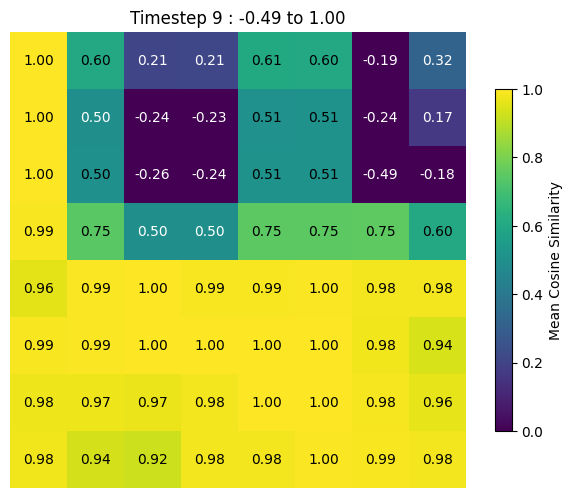

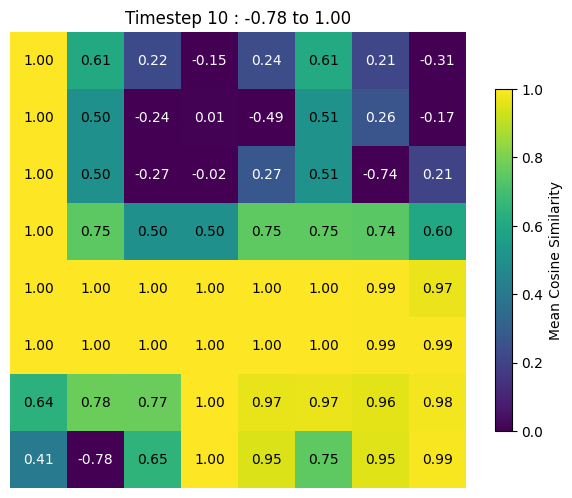

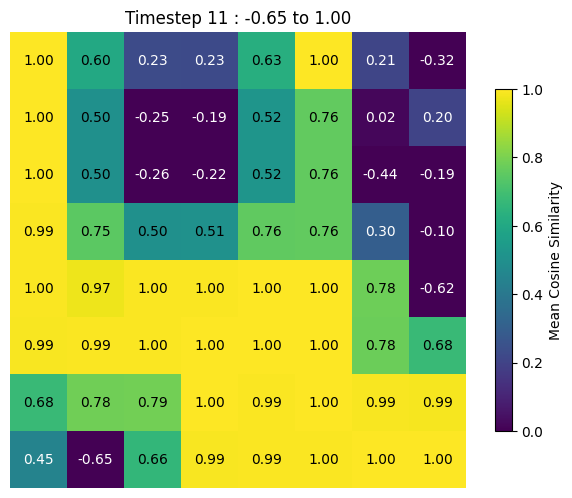

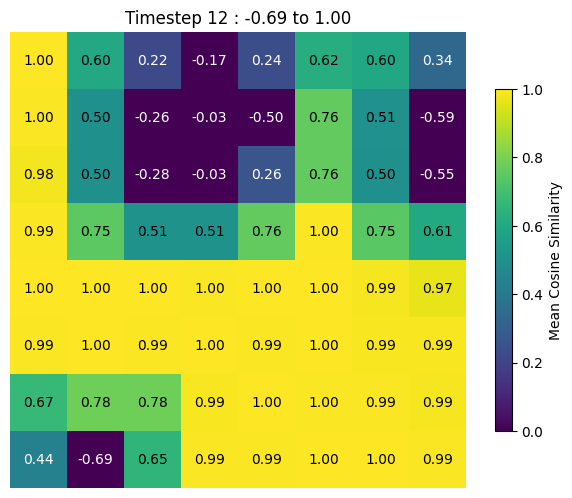

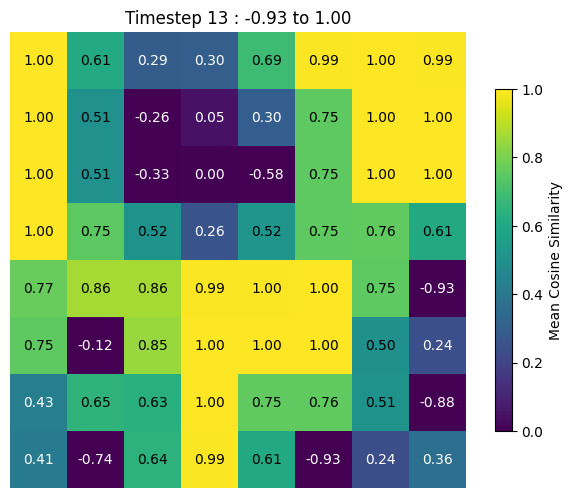

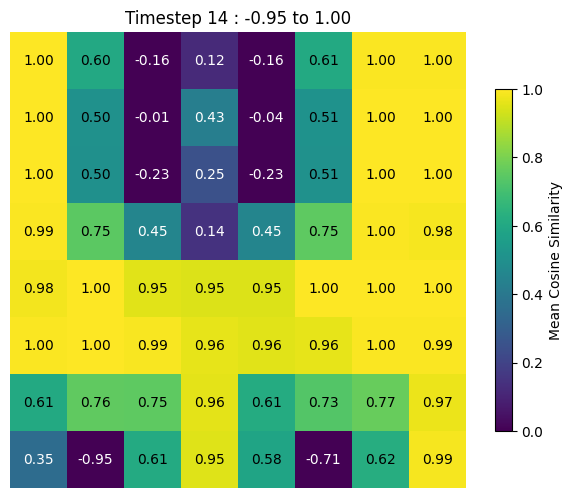

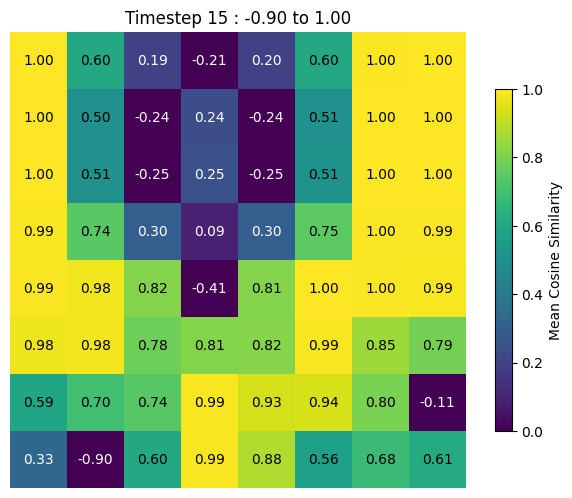

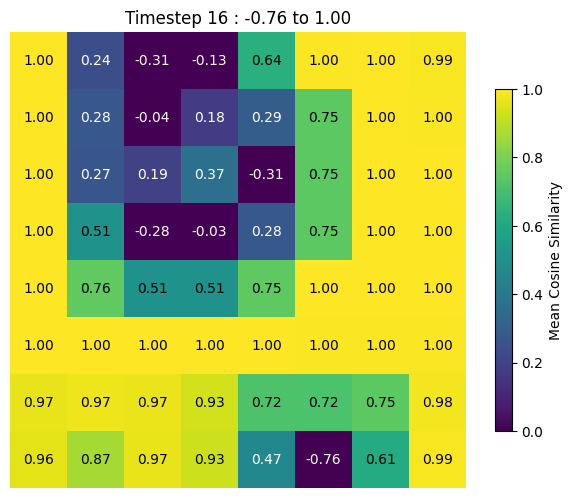

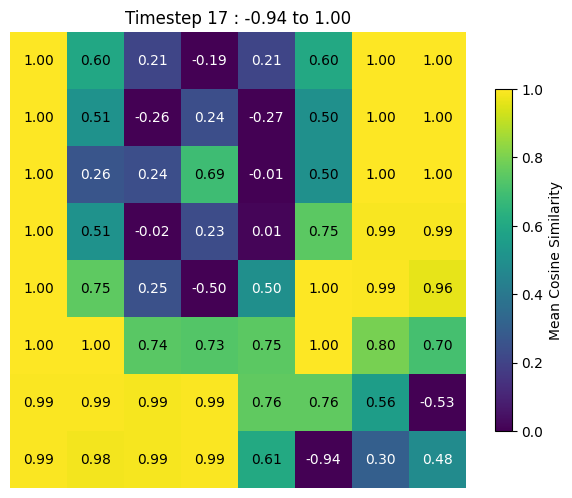

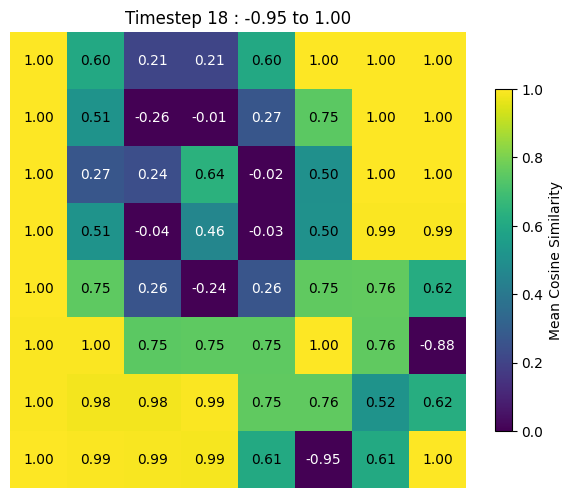

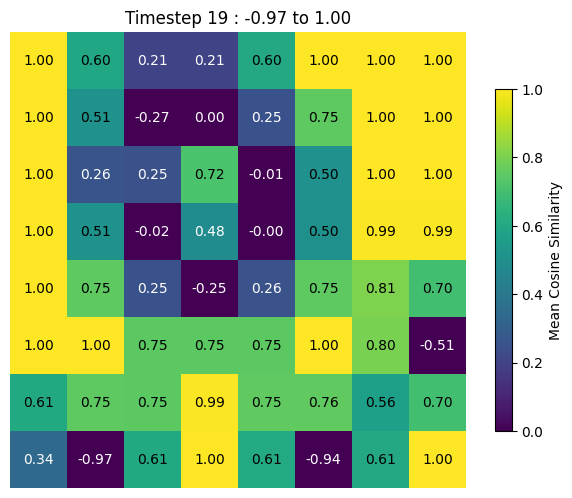

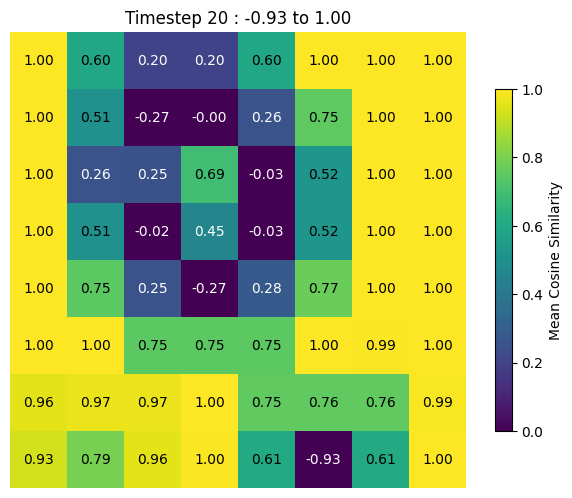

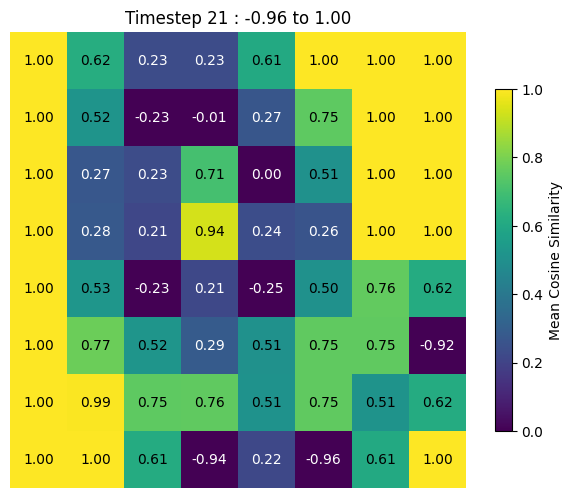

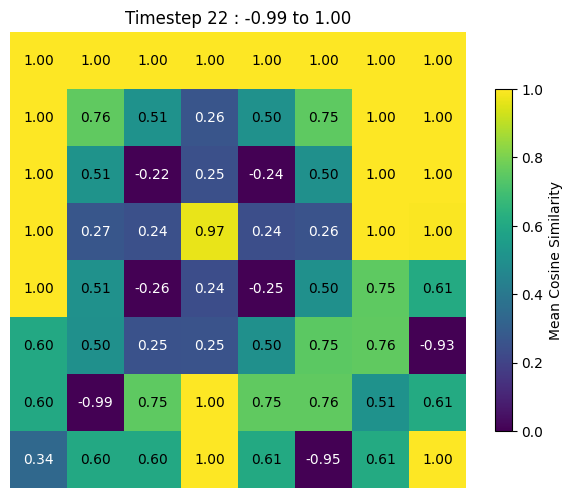

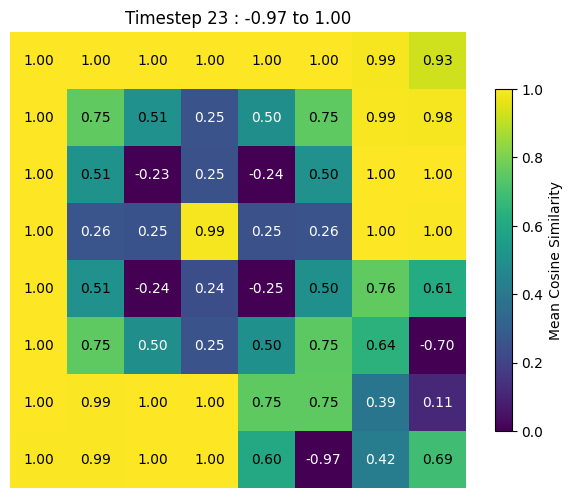

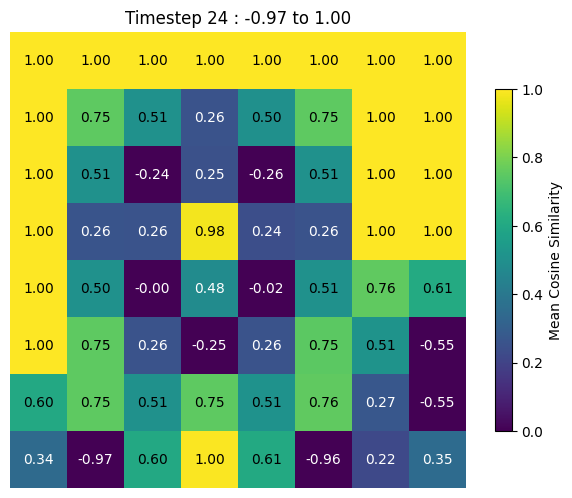

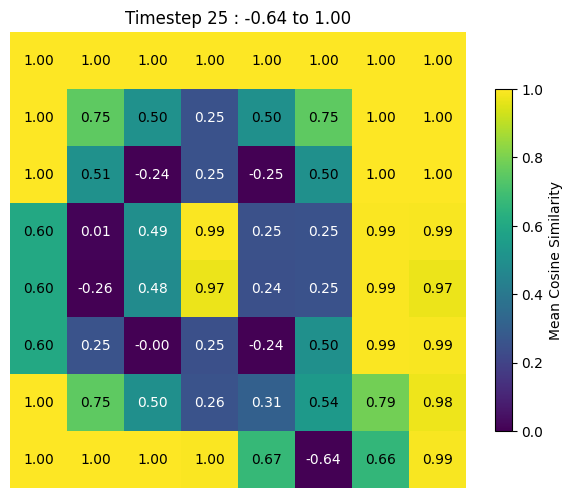

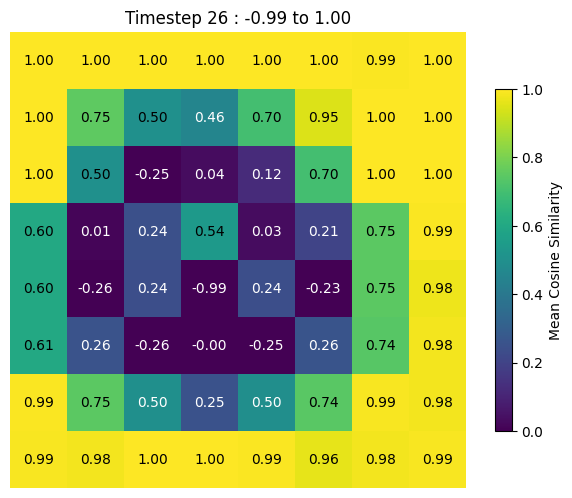

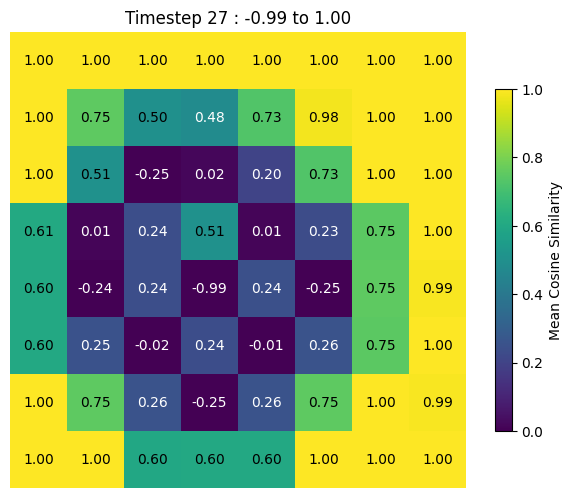

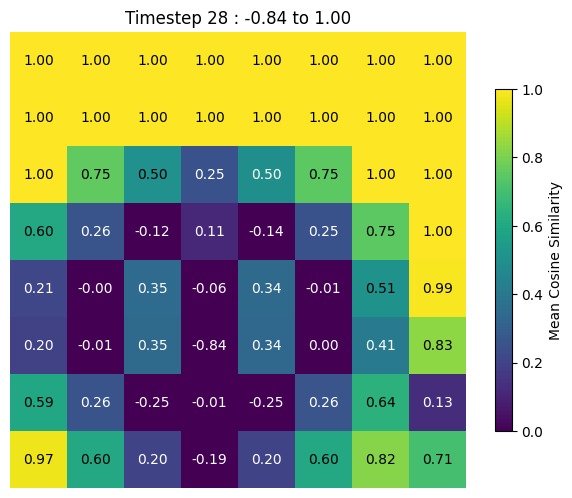

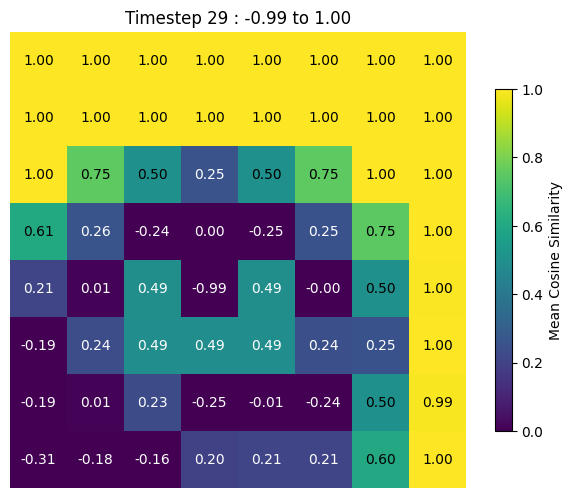

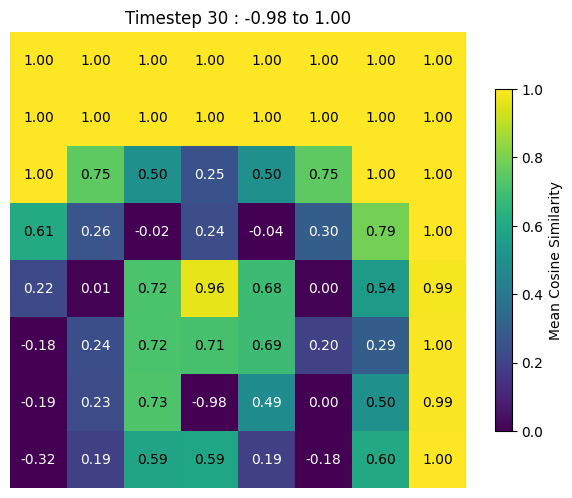

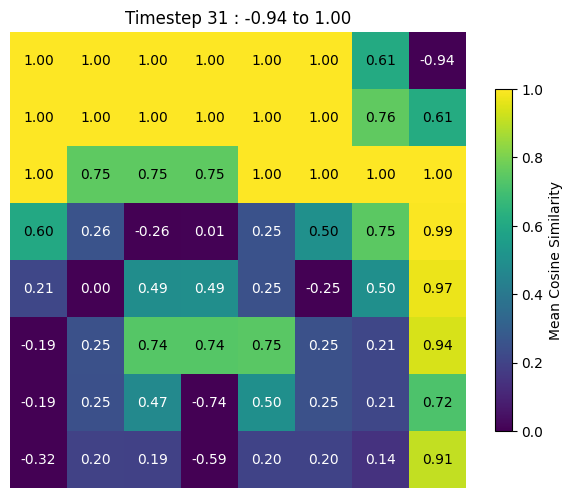

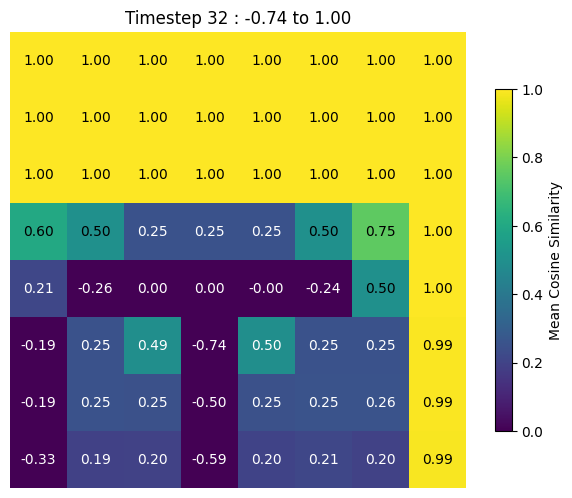

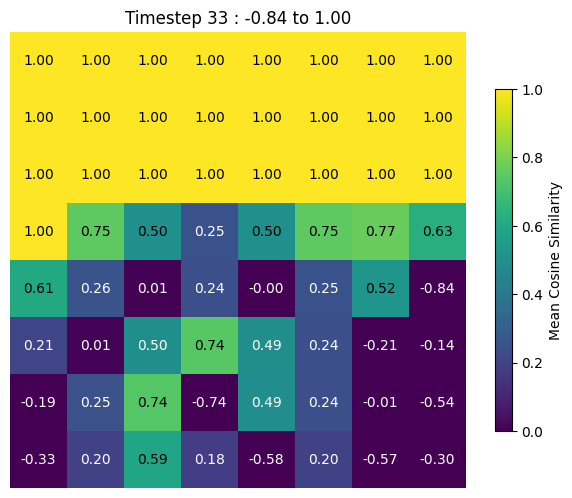

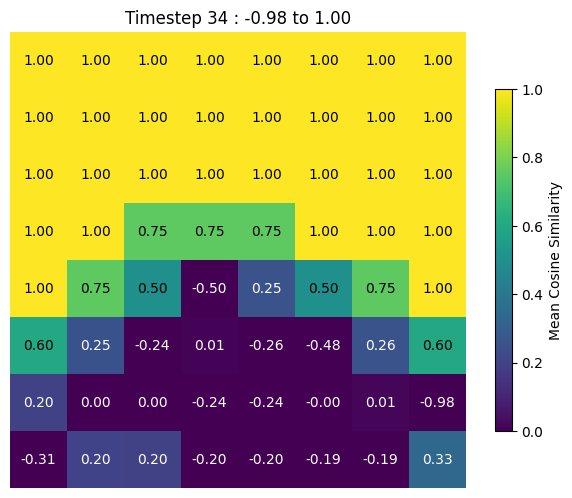

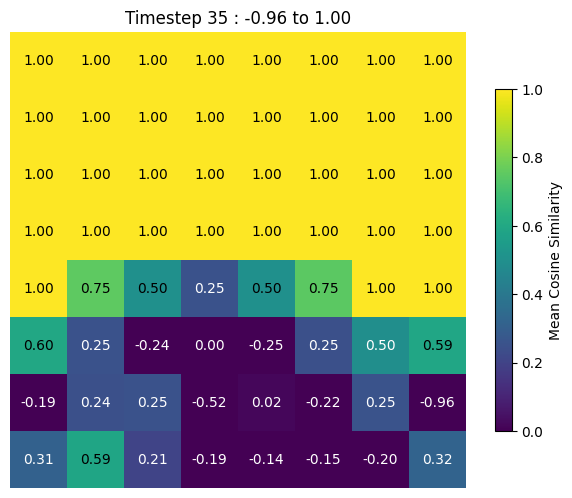

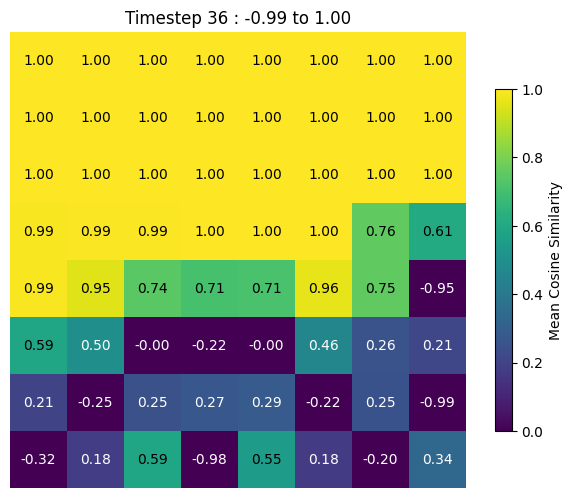

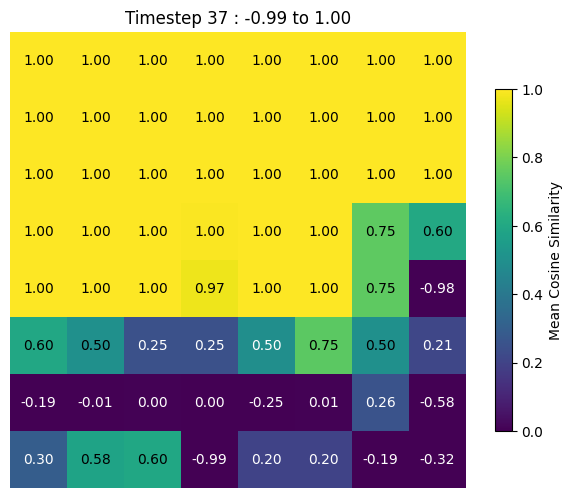

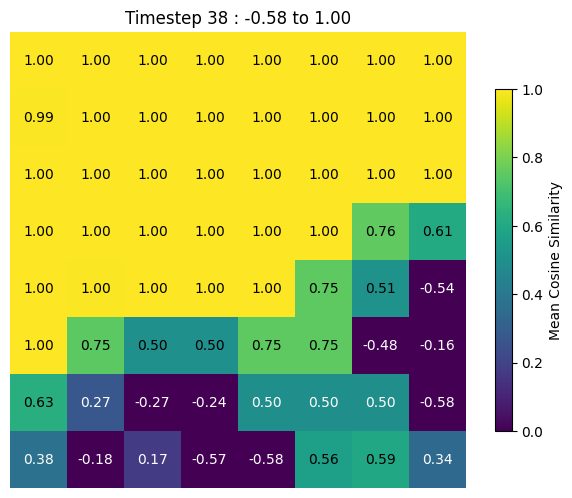

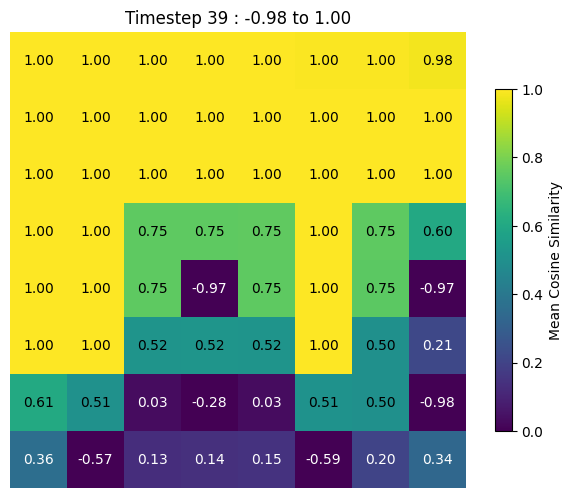

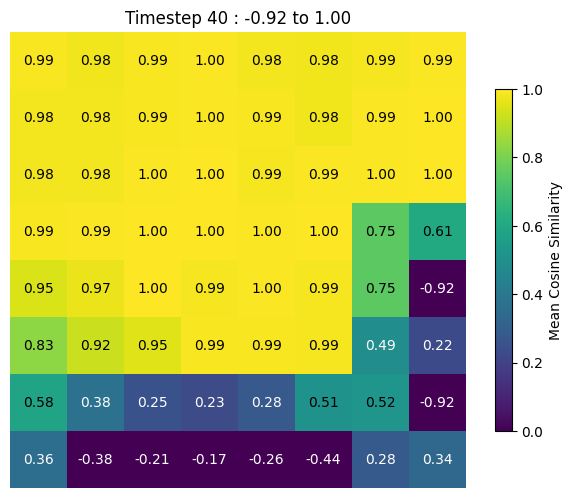

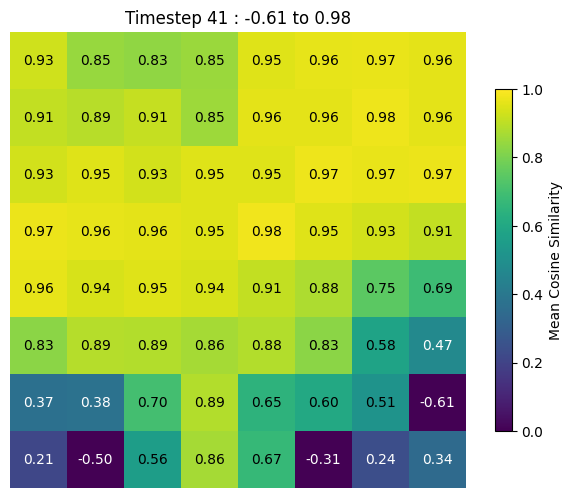

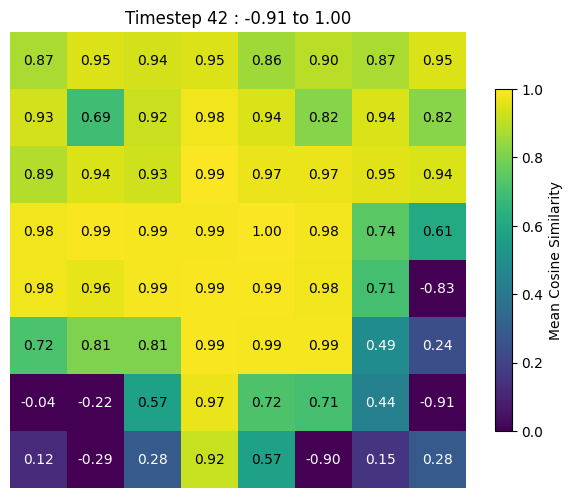

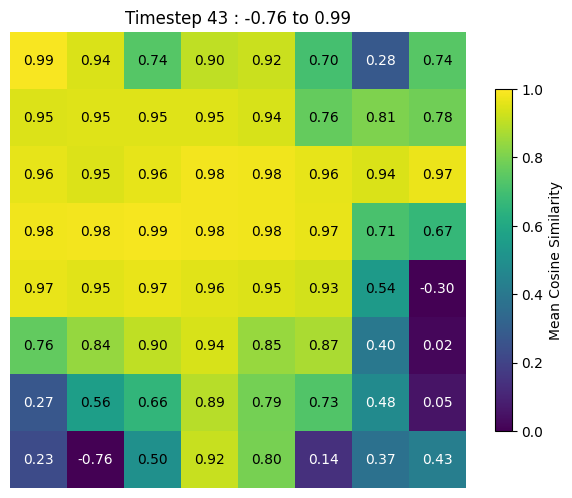

In [120]:
# Plot the heatmaps
for i in range(n):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    im = ax.imshow(results[i], cmap='viridis', vmin=0, vmax=1)
    for k in range(8):
        for j in range(8):
            value = results[i][k, j]
            plt.text(j, k, f"{value:.2f}", ha='center', va='center', color='white' if value < 0.5 else 'black', fontsize=10)

    ax.set_title(f"Timestep {i} : {results[i].min().item():.2f} to {results[i].max().item():.2f}")
    ax.axis('off')

    fig.colorbar(im, ax=ax, shrink=0.6, label='Mean Cosine Similarity')
    plt.tight_layout()
    plt.show()